# **Objective**
#### This notebook focuses on utilizing a **Transformer model** for **image captioning** on a **small dataset**. **Image captioning** is a fascinating task that **combines computer vision** and **natural language processing** to **generate** meaningful **textual descriptions based on visual content**. The primary goal is to offer a **comprehensive resource** for individuals interested in **building** and **understanding** transformer models. It serves as a **step-by-step guide**, explaining the construction of a **transformer model** and the process of building it for **Image Captioning** tasks.

### What is a **Transformer** ?
> ##### A Transformer is a type of **deep learning model architecture** that is designed to **handle sequential data**, making it particularly **well-suited** for **Natural Language Processing (NLP)** tasks such as **machine translation**, and **text summarization**. Unlike **Recurrent Neural Networks (RNN)s** and **Long Short-Term Memory Networks (LSTMs)**, **transformers** allow for **parallelization** of training, making them **highly efficient** for both training and inference. **Notable transformer-based models** include **BERT** and **GPT**.
>###### For **more information** please refer to **the paper** titled **"Attention is All You Need"** by **Vaswani et al.**, published in **2017**.

>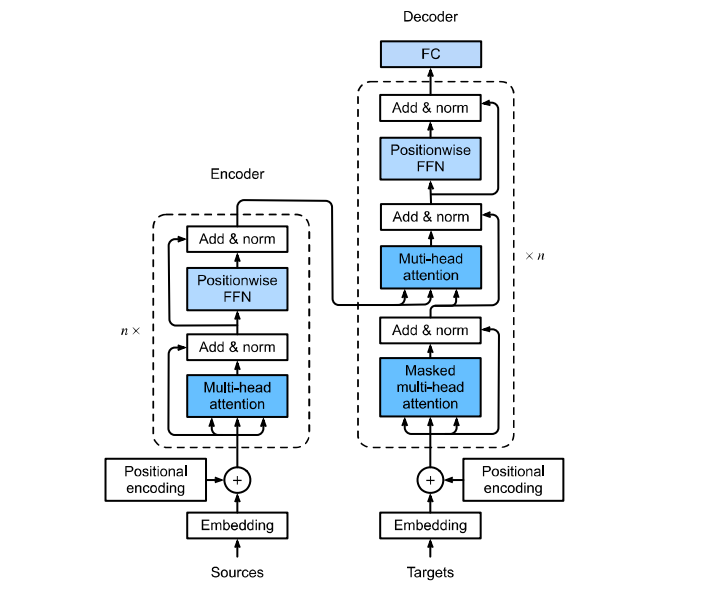

> ##### **Input Embedding:** Captures **semantic relationships** between words by embedding them into a continuous vector space.

> ##### **Positional Encoding:** Provides information about the **positions** of words in a sequence. (**non-trainable**)
> ##### **Multi-Head Attention:** Captures diverse aspects of the **relationships** between words by attending to different parts of the input sequence simultaneously.
> ##### **Mask:** **Enables** the model to **disregard** both future tokens and padding tokens.
> ##### **Multi-Head Cross-Attention:** This layer **is designed to attend to both** the input sequence and the output of the encoder. Attention mechanism, specifically the **cross-attention** layer, **is capable of handling inputs with varying lengths**. 

## Methodology:
> #### 1. **Data and Pre-processing:**
> ##### The **Flickr8k** dataset is utilized, and pre-processing involves **caption normalization**, **length filtering**, and dataset splitting. **Image processing** functions, such as decoding, and **resizing**, are implemented. The dataset is prepared using **TensorFlow** functions, including shuffling, **mapping**, **batching**, and **prefetching for optimal parallelization**.
> #### 2. **Model Architecture:**
> ##### The model architecture comprises a pre-trained **EfficientNetB0 CNN** for **image feature extraction**. The extracted features undergo **normalization** and **dense** layers to **align dimensions** with the **encoder**. **The encoder** incorporates **multi-head attention** and **layer normalization**. **The decoder**, fed with **the target caption and encoder's output**, employs **positional embedding**, **masked multi-head attention**, **layer normalization**, **multi-head cross-attention**, **feed-forward layers**. **Ultimately** a **Dense layer** with **softmax** activation serves as **the output layer**.
> #### 3. **Training:**
> ##### **The model** will be trained using the **images** as inputs **for encoder** and **their corresponding 5 captions[:, :-1]** (excluding the <end\> token) as inputs **for decoder**. **The target** captions will consist of **the corresponding five captions[:, 1:]** (excluding the <start\> token). The primary objective is to **update weights** and **minimize the loss** during training.
> #### 4. **Inference:**
> ##### **Sparse Categorical Crossentropy loss** is used for validation **during training**, while the **Greedy algorithm** combined with **BLEU score evaluation** is employed for **generating captions** on **test set**.

## Library setup

In [5]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import warnings
warnings.filterwarnings('ignore')
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import tensorflow as tf
import keras
from keras import layers
from keras.applications import efficientnet
from tensorflow.keras.utils import to_categorical, plot_model
from keras.layers import TextVectorization
from keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split
from nltk.translate.bleu_score import corpus_bleu
from tqdm import tqdm_notebook
from collections import Counter

# By setting a random seed, we ensure that the sequence of random numbers generated during training,
                                                  # remains the same across different runs of the code.


In [6]:
# =========================================================
# FIX ALL RANDOMNESS
# =========================================================
import os
import random
import numpy as np
import tensorflow as tf

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("✅ Random seed fixed:", SEED)


✅ Random seed fixed: 42


# Data and Pre-processing

In [24]:
# Path to the images
IMAGES_PATH = "/kaggle/input/flickr8k/Images"
# Path to the captions
CAPTIONS_PATH = "/kaggle/input/flickr8k/captions.txt"

# Desired image dimensions


# Number of epochs
EMBED_DIM = 384          # ↓ from 512
FF_DIM = 768             # 2× EMBED_DIM
NUM_HEADS = 6            # ↓ from 8

NUM_ENCODER_LAYERS = 1   # ✔️ keep
NUM_DECODER_LAYERS = 2   # ↓ from 3

DROPOUT = 0.3            # ↑ from 0.1
DROPOUT_RATE = 0.3

LEARNING_RATE = 1e-5     # ✔️ keep
WEIGHT_DECAY = 1e-4      # ✔️ keep

SEQ_LENGTH = 27          # ✔️ perfect

In [25]:
# Loads captions (text) data and maps them to corresponding images.
import csv
import os
# =========================================================
# LOAD CAPTIONS CORRECTLY
# =========================================================
import csv
import os



In [30]:
# Loads captions (text) data and maps them to corresponding images.
import csv
import os
# =========================================================
# LOAD CAPTIONS CORRECTLY
# =========================================================
import csv
import os

def load_captions_data(filename):
    caption_mapping = {}
    text_data = []
    images_to_skip = set()

    with open(filename, "r", encoding="utf-8") as f:
        reader = csv.reader(f)
        next(reader)  # skip header

        for row in reader:
            if len(row) != 2:
                continue

            img_name, caption = row
            img_name = os.path.join(IMAGES_PATH, img_name.strip())
            caption = caption.strip()

            tokens = caption.split()

            # Skip bad captions
            if len(tokens) < 4 or len(tokens) > SEQ_LENGTH:
                images_to_skip.add(img_name)
                continue

            if img_name.endswith(".jpg"):
                caption = "<start> " + caption + " <end>"
                text_data.append(caption)

                if img_name not in caption_mapping:
                    caption_mapping[img_name] = []

                caption_mapping[img_name].append(caption)

    # Remove images with bad captions
    for img in images_to_skip:
        caption_mapping.pop(img, None)

    print("✅ Captions loaded:", len(caption_mapping))
    return caption_mapping, text_data


    return caption_mapping, text_data


In [31]:
captions_mapping, text_data = load_captions_data(CAPTIONS_PATH)


✅ Captions loaded: 7960


In [34]:
# =========================================================
# DETERMINISTIC SPLIT (NO FILE SAVING)
# =========================================================

def create_split(IMAGES_PATH,
                 caption_mapping,
                 train_ratio=0.9,
                 val_ratio=0.08,
                 seed=42):

    # 1️⃣ Use SAME base list as LSTM
    all_images = sorted(os.listdir(IMAGES_PATH))
    all_images = [os.path.join(IMAGES_PATH, img) for img in all_images]

    # 2️⃣ Deterministic shuffle
    rng = np.random.default_rng(seed)
    rng.shuffle(all_images)

    # 3️⃣ Compute indices
    total = len(all_images)
    train_end = int(total * train_ratio)
    val_end = train_end + int(total * val_ratio)

    train_keys = all_images[:train_end]
    val_keys   = all_images[train_end:val_end]
    test_keys  = all_images[val_end:]

    # 4️⃣ Keep only images that exist in caption_mapping
    train_data = {k: caption_mapping[k] for k in train_keys if k in caption_mapping}
    val_data   = {k: caption_mapping[k] for k in val_keys if k in caption_mapping}
    test_data  = {k: caption_mapping[k] for k in test_keys if k in caption_mapping}

    print("✅ Split created")
    print("Train:", len(train_data))
    print("Val:", len(val_data))
    print("Test:", len(test_data))

    return train_data, val_data, test_data


In [35]:
train_data, val_data, test_data = create_split(
    IMAGES_PATH,
    captions_mapping,
    seed=42
)


✅ Split created
Train: 7165
Val: 633
Test: 162


In [36]:
train_ids_trans = sorted(list(train_data.keys()))
val_ids_trans = sorted(list(val_data.keys()))
test_ids_trans = sorted(list(test_data.keys()))

print("Transformer first 5 train images:", train_ids_trans[:5])


Transformer first 5 train images: ['/kaggle/input/flickr8k/Images/1000268201_693b08cb0e.jpg', '/kaggle/input/flickr8k/Images/1001773457_577c3a7d70.jpg', '/kaggle/input/flickr8k/Images/1002674143_1b742ab4b8.jpg', '/kaggle/input/flickr8k/Images/1003163366_44323f5815.jpg', '/kaggle/input/flickr8k/Images/1007129816_e794419615.jpg']


## Defining **the vectorizer** with custom standardization and image augmentation

In [38]:
# Vocabulary size
VOCAB_SIZE = 10000

In [39]:
def custom_standardization(input_string):
    # Lowercasing all of the captions
    lowercase = tf.strings.lower(input_string)
    # Charecters to remove
    strip_chars = "!\"#$%&'()*+,-./:;=?@[\]^_`{|}~1234567890"
    return tf.strings.regex_replace(lowercase, "[%s]" % re.escape(strip_chars), "")

# Defining the vectorizer
vectorization = TextVectorization(
    # Number of unique tokens
    max_tokens=VOCAB_SIZE,
    output_mode="int",
    # Maximum length of captions. Padding tokens(zeros) will be added to shorter captions.
    output_sequence_length=SEQ_LENGTH,
    # Standardizing the captions
    standardize=custom_standardization)

# Adapting the vectorizer with the captions
vectorization.adapt(text_data)

# Data augmentation for image data
image_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.2),
])

# Standardizing the text data
text_data = list(map(lambda x: str(custom_standardization(x).numpy())[2:-1], text_data))

## Visualizing some of the images along with the corresponding captions

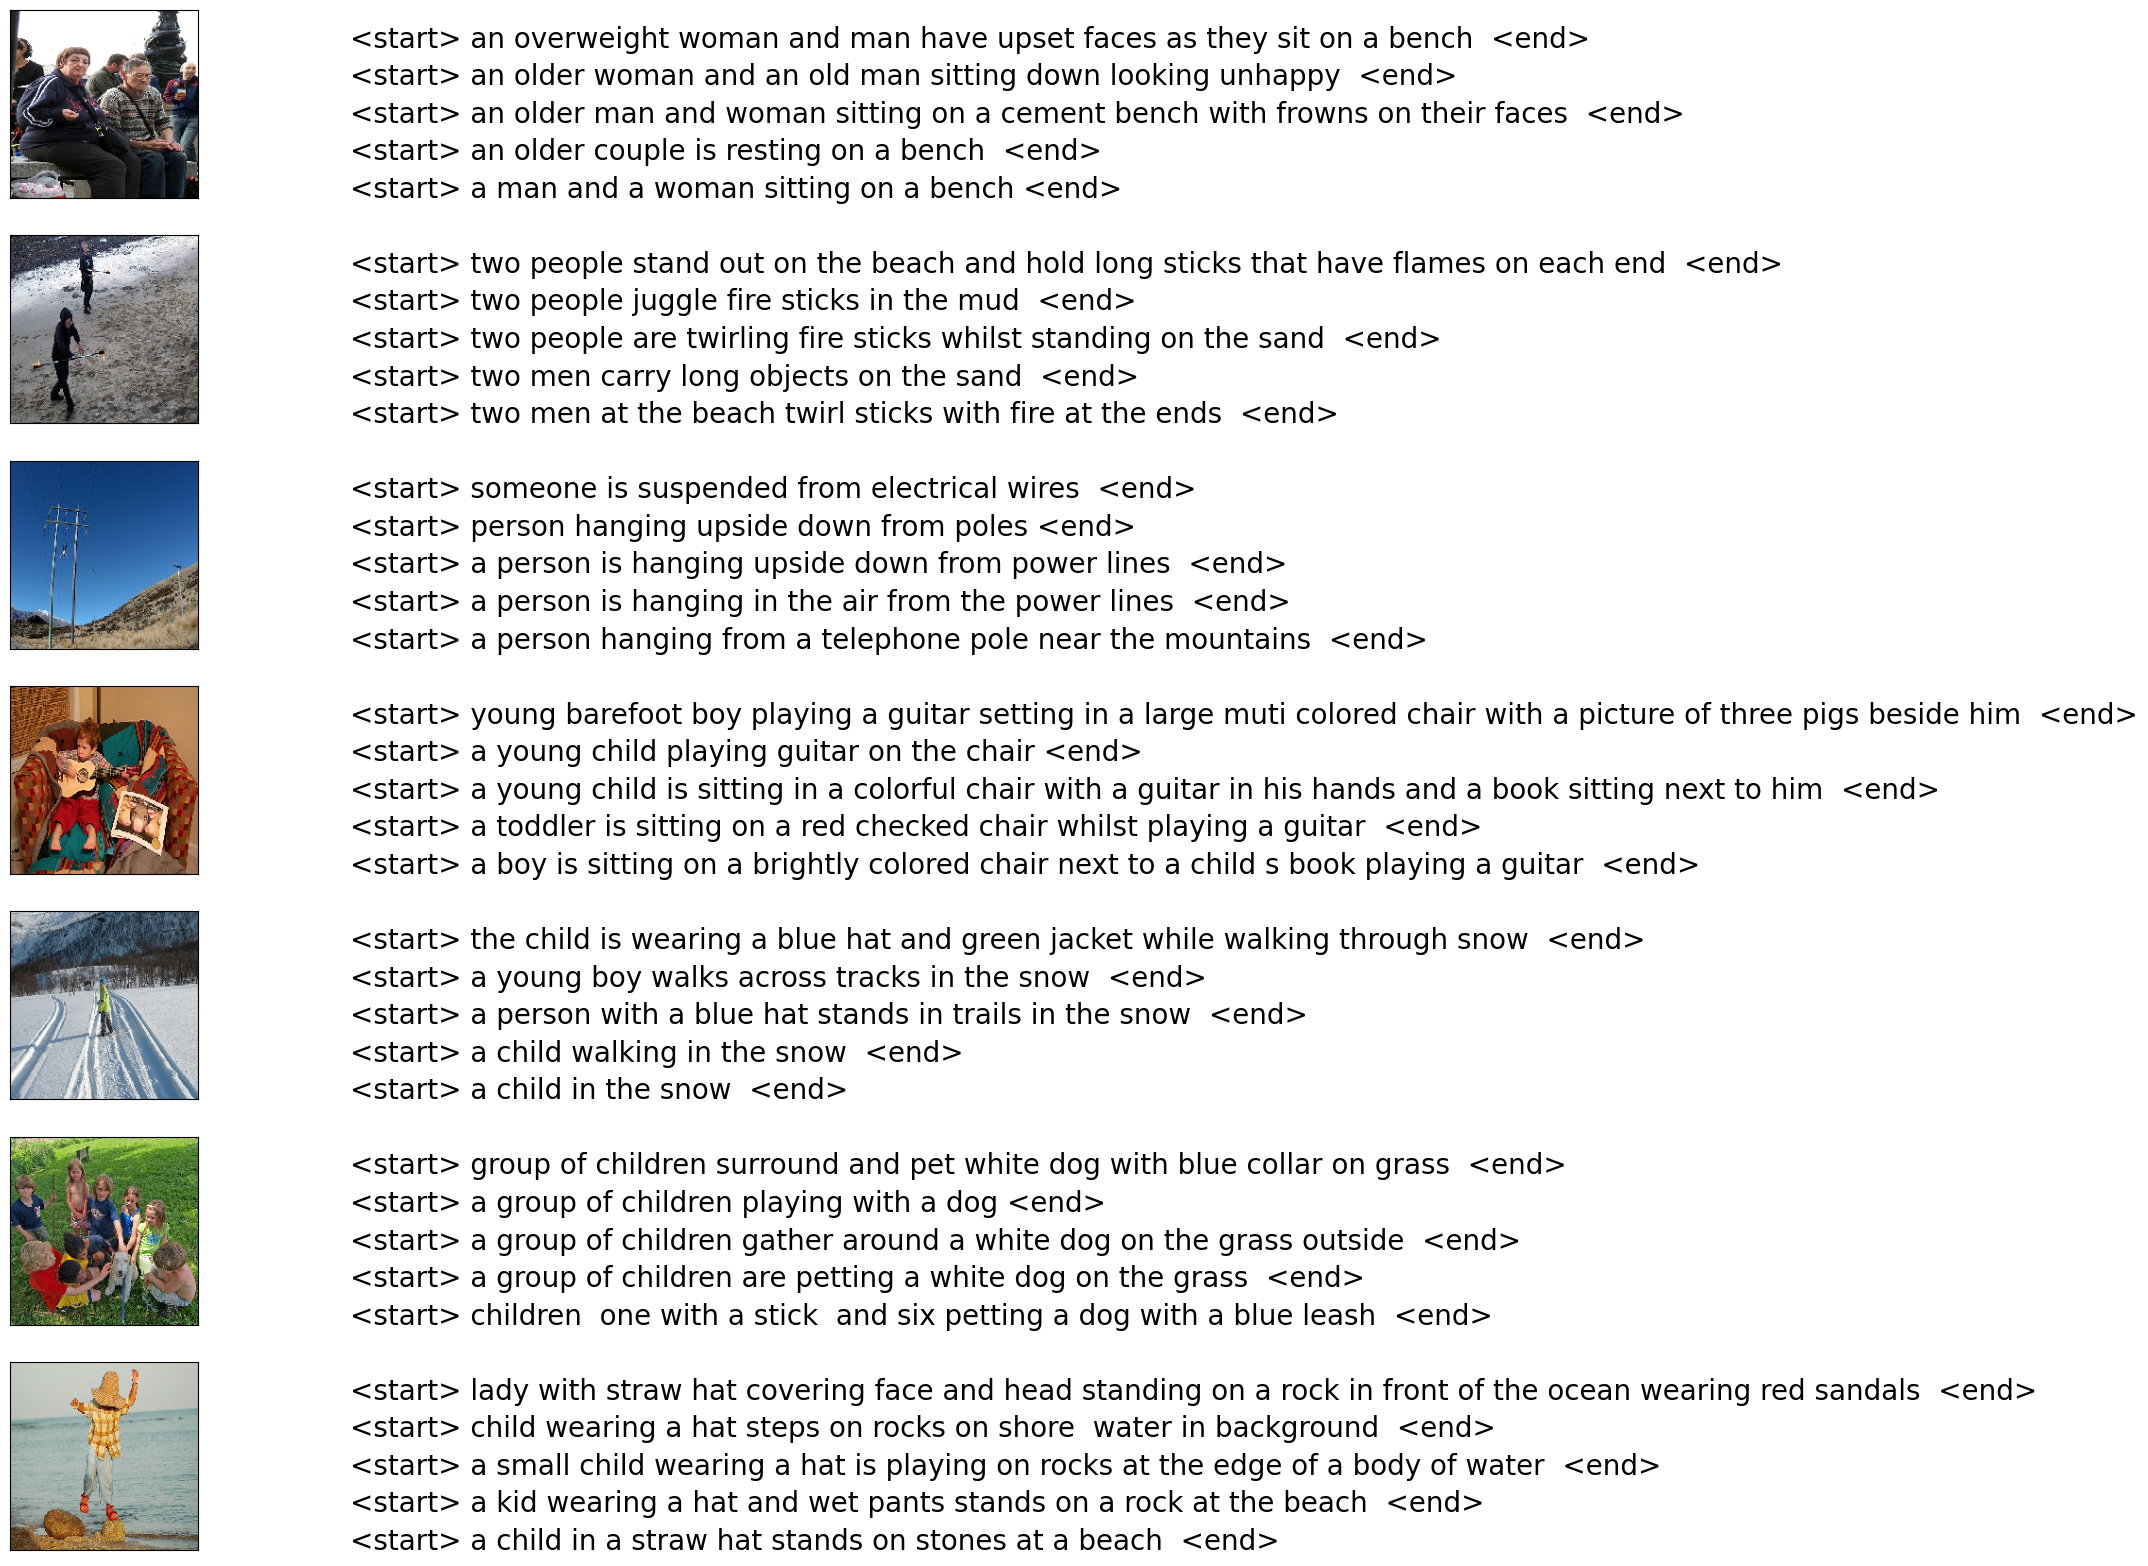

In [40]:
def visualaization(data, num_of_images):
    count = 1
    fig = plt.figure(figsize=(10,20))
    for filename in list(data.keys())[100:100+num_of_images]:
        captions = list(map(lambda x: str(custom_standardization(x).numpy())[2:-1], data[filename]))
        image_load = load_img(filename, target_size=(199,199,3))

        ax = fig.add_subplot(num_of_images,2,count,xticks=[],yticks=[])
        ax.imshow(image_load)
        count += 1

        ax = fig.add_subplot(num_of_images,2,count)
        plt.axis('off')
        ax.plot()
        ax.set_xlim(0,1)
        ax.set_ylim(0,len(captions))
        for i, caption in enumerate(captions):
            ax.text(0,i,caption,fontsize=20)
        count += 1
    plt.show()
    
visualaization(train_data, 7)

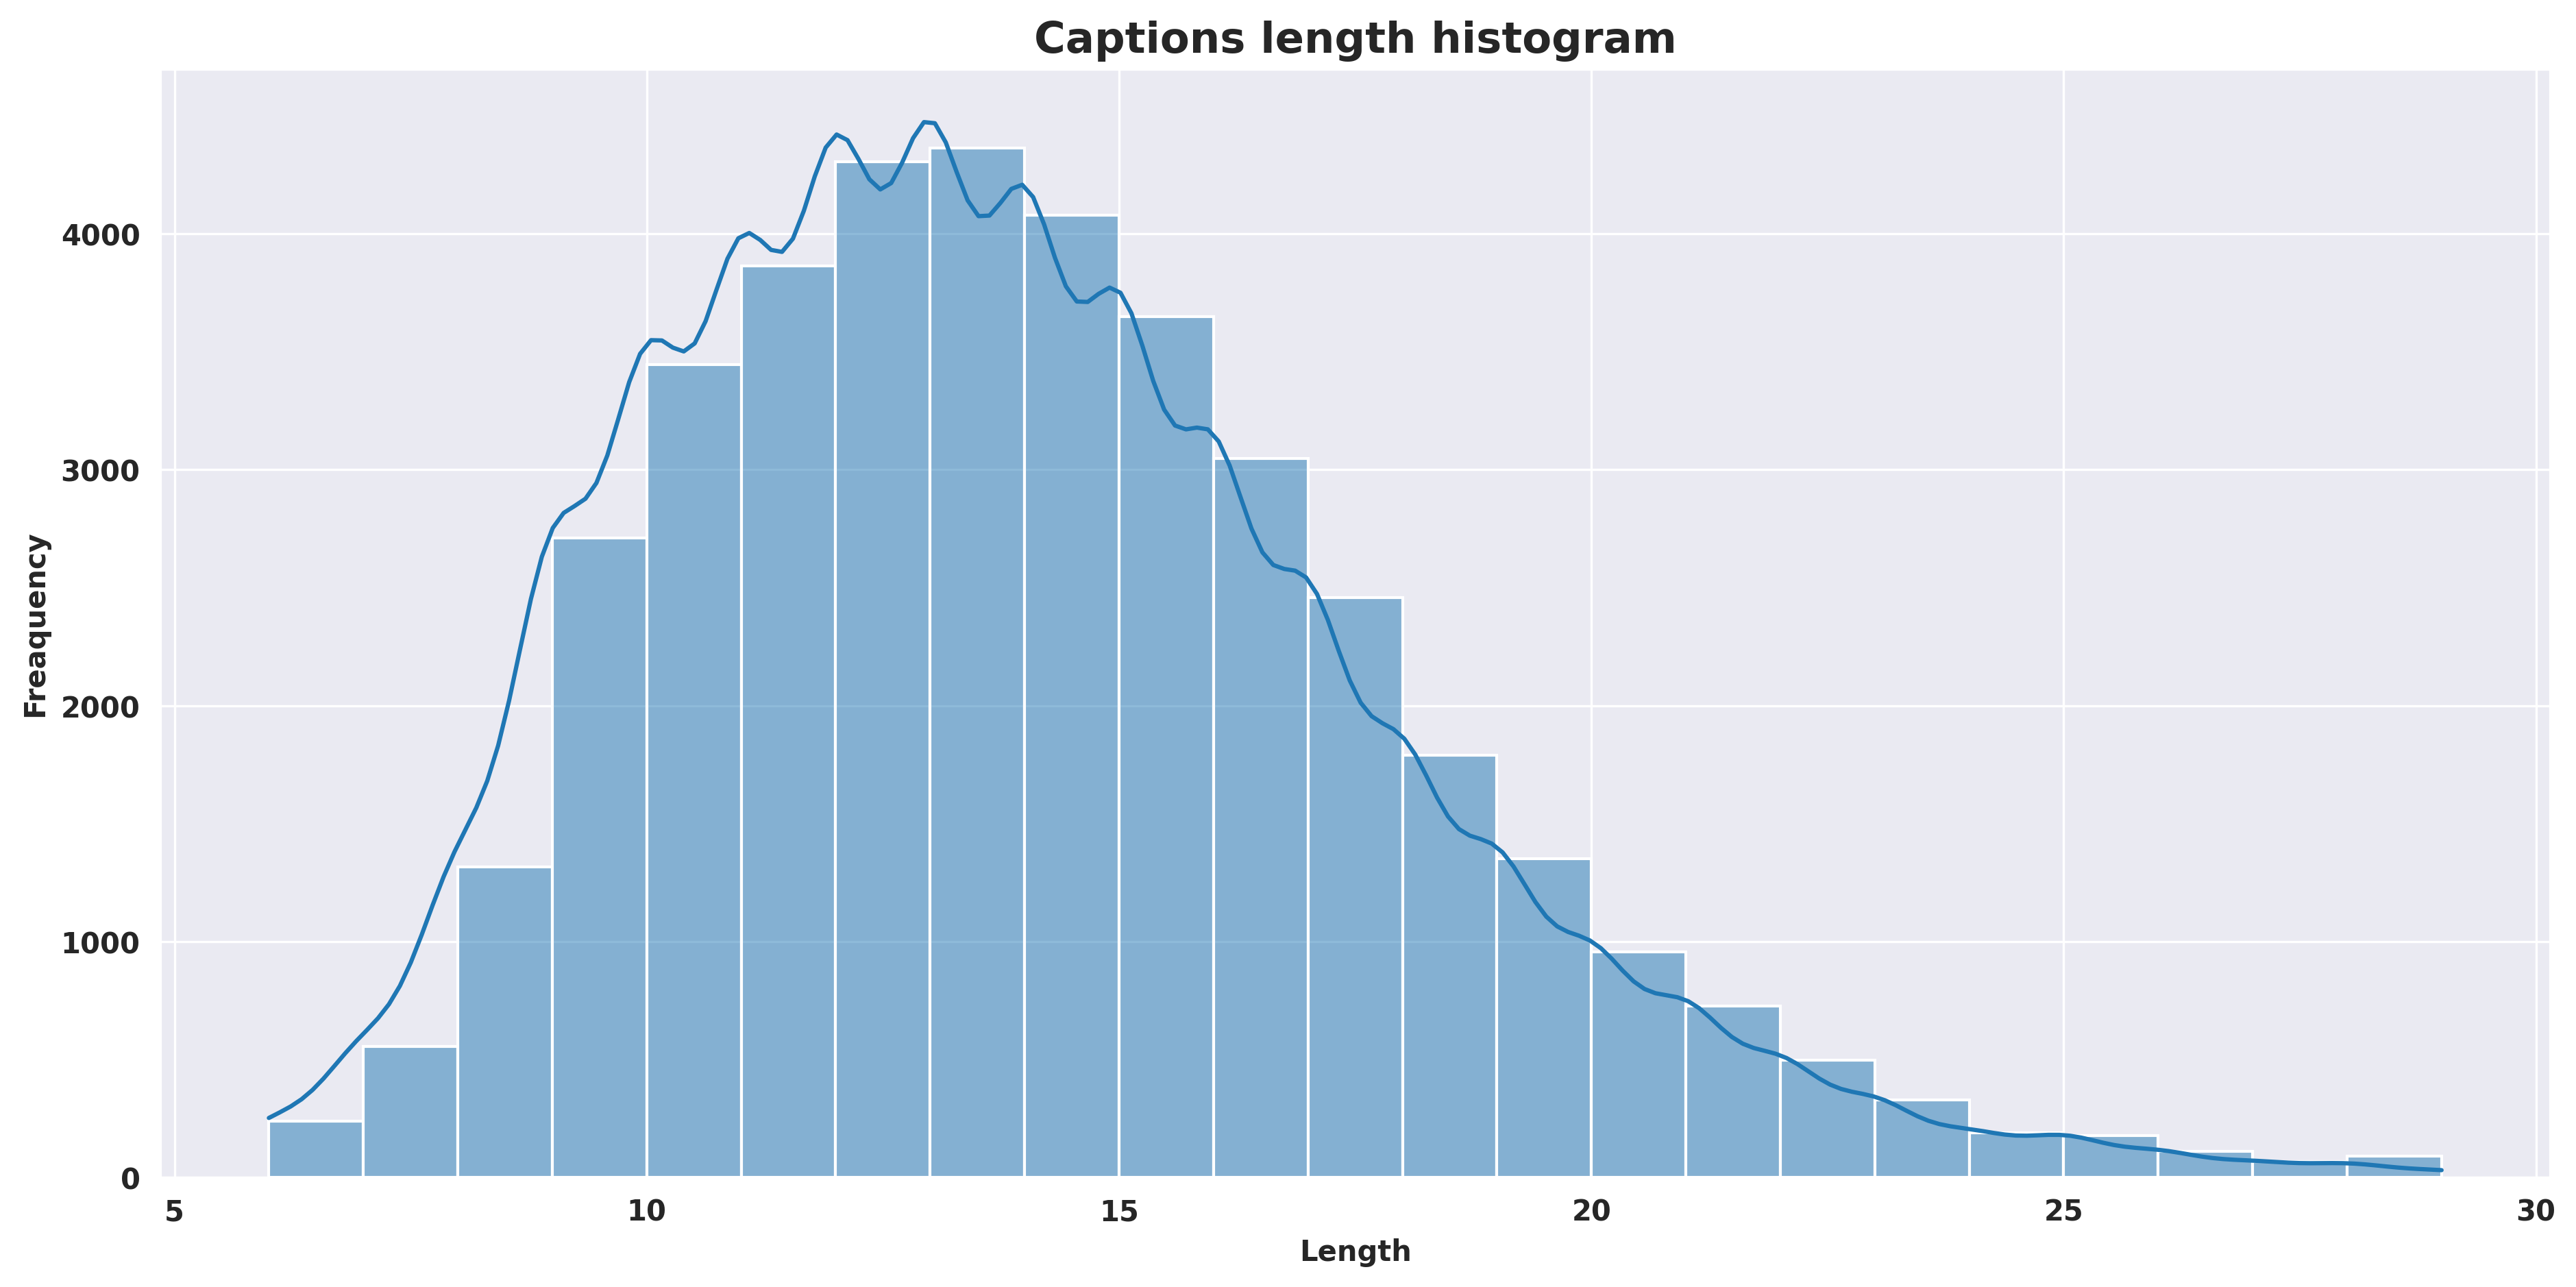

In [41]:
def captions_length(data):
    plt.figure(figsize=(15, 7), dpi=300)
    sns.set_style('darkgrid')
    sns.histplot(x=[len(x.split(' ')) for x in data], kde=True, binwidth=1) 
    plt.title('Captions length histogram', fontsize=15, fontweight='bold')
    plt.xticks(fontweight='bold')
    plt.yticks(fontweight='bold')
    plt.xlabel('Length', fontweight='bold')
    plt.ylabel('Freaquency', fontweight='bold')
    plt.show()
    
captions_length(text_data)

In [42]:
def word_occurrences(data):
    # Combining all sentences into a single string
    all_text = ' '.join(data)
    all_text = all_text.replace('a ', '')
    all_text = all_text.replace('<start> ', '')
    all_text = all_text.replace('<end> ', '')
    # Splitting the text into words and count occurrences
    word_counts = Counter(all_text.split())

    words = list(word_counts.keys())[:30]
    values = list(word_counts.values())[:30]

    # Normalize values to be between 0 and 1
    normalized_values = np.array(values) / np.max(values)
    colors = np.array(['rgba(30, 58, 138, {})'.format(0.4 + 0.5 * (value)) for value in normalized_values])

    fig = go.Figure(data=[go.Pie(labels=words, values=values, hole=.6, marker=dict(colors=colors), textinfo='label')])

    fig.update_layout(title_text='Word occurrences in captions (except for letter \'a\')', title_font=dict(size=23, family='Balto'))

    fig.show()
    
word_occurrences(text_data)

# **Data Setup for Model Input**
##### **Parallelization** Involves **breaking down a task** into **smaller subtasks** that can be **executed in parallel**.
##### **'tf.data.AUTOTUNE'** determines the **optimal** level of **parallelism**.

In [44]:
BATCH_SIZE = 32
IMAGE_SIZE = (224, 224)

In [45]:
# Processes the images
def decode_and_resize(img_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMAGE_SIZE)
    img = tf.image.convert_image_dtype(img, tf.float32)
    return img

def process_input(img_path, captions):
    # Processed images + vectorized captions
    return decode_and_resize(img_path), vectorization(captions)

def make_dataset(images, captions):
    dataset = tf.data.Dataset.from_tensor_slices((images, captions))
    dataset = dataset.shuffle(BATCH_SIZE * 8)
    dataset = dataset.map(process_input, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return dataset

# Use correct dict names
train_dataset = make_dataset(list(train_data.keys()), list(train_data.values()))
validation_dataset = make_dataset(list(val_data.keys()), list(val_data.values()))
test_dataset = make_dataset(list(test_data.keys()), list(test_data.values()))

print("✅ Datasets ready")
print("Train batches:", len(train_dataset))
print("Validation batches:", len(validation_dataset))
print("Test batches:", len(test_dataset))


✅ Datasets ready
Train batches: 224
Validation batches: 20
Test batches: 6


# **Defining** the **Image Captioning** Model

> ### **CNN** (feature extraction)
> * Pre-Trained model: EfficientNetB0

> ### **Encoder** (embedded image features)
> * Layer Normalization Layer
> * Dense Layer
> * Multi-Head Attention Layer
> * Layer Normalization Layer

> ### **Decoder** (embedded captions)
> * Positional Embedding Layer (input embedding + positional encoding)
> * Mask (enables the model to ignore both padding tokens and future tokens)
> * Multi-Head Attention Layer
> * Layer Normalization Layer
> * Multi-Head Cross-Attention Layer
> * Layer Normalization Layer
> * Feed Forward Layer
> * Layer Normalization Layer

> ### **Output**
> * Dense Layer + Softmax activation function

In [46]:

from tensorflow.keras import layers
from tensorflow import keras
import tensorflow as tf


from tensorflow.keras import layers, Model
from tensorflow.keras.applications import efficientnet

from tensorflow.keras import layers, Model
from tensorflow.keras.applications import efficientnet

def get_cnn_model():
    base_model = efficientnet.EfficientNetB0(
        input_shape=(*IMAGE_SIZE, 3),
        include_top=False,
        weights="imagenet",
    )

    base_model.trainable = False  # freeze first

    x = base_model.output
    x = layers.Reshape((-1, x.shape[-1]))(x)
    x = layers.Dense(EMBED_DIM)(x)
    x = layers.LayerNormalization()(x)

    model = Model(base_model.input, x)
    model.backbone = base_model  # ⭐ VERY IMPORTANT

    return model










# =========================================================
# 2️⃣ TRANSFORMER ENCODER
# =========================================================

class TransformerEncoderBlock(layers.Layer):
    def __init__(self, embed_dim, ff_dim, num_heads, dropout=0.1):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads, embed_dim)
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(embed_dim),
        ])
        self.norm1 = layers.LayerNormalization()
        self.norm2 = layers.LayerNormalization()
        self.dropout = layers.Dropout(dropout)

    def call(self, x, training=False):
        attn = self.att(self.norm1(x), self.norm1(x))
        x = x + self.dropout(attn, training=training)

        ffn = self.ffn(self.norm2(x))
        x = x + self.dropout(ffn, training=training)
        return x

# =========================================================
# 3️⃣ POSITIONAL EMBEDDING
# =========================================================
class PositionalEmbedding(layers.Layer):
    def __init__(self, sequence_length, vocab_size, embed_dim, dropout=0.1):
        super().__init__()
        self.token_embeddings = layers.Embedding(vocab_size, embed_dim)
        self.position_embeddings = layers.Embedding(sequence_length, embed_dim)
        self.scale = tf.math.sqrt(tf.cast(embed_dim, tf.float32))
        self.dropout = layers.Dropout(dropout)

    def call(self, x, training=False):
        positions = tf.range(0, tf.shape(x)[-1])
        x = self.token_embeddings(x) * self.scale
        x = x + self.position_embeddings(positions)
        return self.dropout(x, training=training)

    def compute_mask(self, inputs, mask=None):
        return tf.not_equal(inputs, 0)


# =========================================================
# 4️⃣ TRANSFORMER DECODER
# =========================================================
class TransformerDecoderBlock(layers.Layer):
    def __init__(self, embed_dim, ff_dim, num_heads, dropout=0.1):
        super().__init__()
        self.embedding = PositionalEmbedding(SEQ_LENGTH, VOCAB_SIZE, embed_dim)

        self.self_att = layers.MultiHeadAttention(num_heads, embed_dim)
        self.cross_att = layers.MultiHeadAttention(num_heads, embed_dim)

        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(embed_dim),
        ])

        self.norm1 = layers.LayerNormalization()
        self.norm2 = layers.LayerNormalization()
        self.norm3 = layers.LayerNormalization()
        self.dropout = layers.Dropout(dropout)

        self.out = layers.Dense(VOCAB_SIZE, activation="softmax")

    def call(self, x, enc_out, training=False, mask=None):
        x = self.embedding(x, training=training)

        seq_len = tf.shape(x)[1]
        causal_mask = tf.linalg.band_part(tf.ones((seq_len, seq_len)), -1, 0)

        att1 = self.self_att(self.norm1(x), self.norm1(x), attention_mask=causal_mask)
        x = x + self.dropout(att1, training=training)

        att2 = self.cross_att(self.norm2(x), enc_out)
        x = x + self.dropout(att2, training=training)

        ffn = self.ffn(self.norm3(x))
        x = x + self.dropout(ffn, training=training)

        return self.out(x)



# =========================================================
# 5️⃣ IMAGE CAPTIONING MODEL
# =========================================================
# =========================================================
# 5️⃣ IMAGE CAPTIONING MODEL (IMPROVED – SAME LOGIC)
# =========================================================
class ImageCaptioningModel(keras.Model):
    def __init__(
        self,
        cnn_model,
        encoder,
        decoder,
        num_captions_per_image=5,
        image_aug=None
    ):
        super().__init__()
        self.cnn_model = cnn_model
        self.encoder = encoder
        self.decoder = decoder
        self.num_captions_per_image = num_captions_per_image
        self.image_aug = image_aug

        # 🔑 Proper loss (label smoothing helps CIDEr & BLEU-4)
        self.loss_fn = keras.losses.SparseCategoricalCrossentropy(
            from_logits=False,
            reduction="none",

        )

        self.loss_tracker = keras.metrics.Mean(name="loss")
        self.acc_tracker = keras.metrics.Mean(name="accuracy")

    def calculate_loss(self, y_true, y_pred, mask):
        loss = self.loss_fn(y_true, y_pred)
        mask = tf.cast(mask, loss.dtype)
        loss *= mask
        return tf.reduce_sum(loss) / tf.reduce_sum(mask)

    def calculate_accuracy(self, y_true, y_pred, mask):
        acc = tf.equal(y_true, tf.argmax(y_pred, axis=-1))
        acc = tf.logical_and(mask, acc)
        acc = tf.cast(acc, tf.float32)
        mask = tf.cast(mask, tf.float32)
        return tf.reduce_sum(acc) / tf.reduce_sum(mask)

    def _compute_loss_acc(self, img_embed, seq, training):
        enc_out = self.encoder(img_embed, training=training)

        seq_in = seq[:, :-1]
        seq_true = seq[:, 1:]
        mask = tf.not_equal(seq_true, 0)

        preds = self.decoder(
            seq_in,
            enc_out,
            training=training,
            mask=mask
        )

        loss = self.calculate_loss(seq_true, preds, mask)
        acc = self.calculate_accuracy(seq_true, preds, mask)
        return loss, acc

    def train_step(self, batch):
        imgs, seqs = batch

        if self.image_aug:
            imgs = self.image_aug(imgs)

        # CNN forward ONCE per image (correct & efficient)
        img_embed = self.cnn_model(imgs)

        total_loss = 0.0
        total_acc = 0.0

        # 🔑 SINGLE GradientTape for all captions
        with tf.GradientTape() as tape:
            for i in range(self.num_captions_per_image):
                loss, acc = self._compute_loss_acc(
                    img_embed,
                    seqs[:, i],
                    training=True
                )
                total_loss += loss
                total_acc += acc

            total_loss /= self.num_captions_per_image
            total_acc /= self.num_captions_per_image

        # 🔑 Train encoder + decoder (CNN frozen or partially fine-tuned)
        train_vars = (
            self.encoder.trainable_variables +
            self.decoder.trainable_variables
        )

        grads = tape.gradient(total_loss, train_vars)

        # 🔑 Gradient clipping (VERY important for Transformer)
        grads, _ = tf.clip_by_global_norm(grads, 1.0)

        self.optimizer.apply_gradients(zip(grads, train_vars))

        self.loss_tracker.update_state(total_loss)
        self.acc_tracker.update_state(total_acc)

        return {
            "loss": self.loss_tracker.result(),
            "accuracy": self.acc_tracker.result()
        }

    def test_step(self, batch):
        imgs, seqs = batch
        img_embed = self.cnn_model(imgs)

        total_loss = 0.0
        total_acc = 0.0

        for i in range(self.num_captions_per_image):
            loss, acc = self._compute_loss_acc(
                img_embed,
                seqs[:, i],
                training=False
            )
            total_loss += loss
            total_acc += acc

        total_loss /= self.num_captions_per_image
        total_acc /= self.num_captions_per_image

        self.loss_tracker.update_state(total_loss)
        self.acc_tracker.update_state(total_acc)

        return {
            "loss": self.loss_tracker.result(),
            "accuracy": self.acc_tracker.result()
        }

    @property
    def metrics(self):
        return [self.loss_tracker, self.acc_tracker]


# =========================================================
# 6️⃣ BUILD MODEL
# =========================================================
cnn_model = get_cnn_model()
encoder = TransformerEncoderBlock(EMBED_DIM, FF_DIM, NUM_HEADS, DROPOUT)
decoder = TransformerDecoderBlock(EMBED_DIM, FF_DIM, NUM_HEADS, DROPOUT)

caption_model = ImageCaptioningModel(
    cnn_model=cnn_model,
    encoder=encoder,
    decoder=decoder,
    image_aug=image_augmentation
)

# Training the model
##### **SparseCategoricalCrossentropy** is **commonly used** for tasks where **each target sequence is a sequence of integers** representing the **class indices**.


In [47]:
from tensorflow_addons.optimizers import AdamW

In [48]:
# =========================================================
# MASKED LOSS
# =========================================================
# =========================================================
# IMPORTS
# =========================================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.optimizers import AdamW   # ✅ SAFE IMPORT

EPOCHS = 40


# =========================================================
# MASKED LOSS
# =========================================================
def masked_loss(y_true, y_pred, label_smoothing=0.1):
    vocab_size = tf.shape(y_pred)[-1]

    y_true_one_hot = tf.one_hot(y_true, depth=vocab_size)

    smooth_pos = 1.0 - label_smoothing
    smooth_neg = label_smoothing / tf.cast(vocab_size, tf.float32)
    y_true_smoothed = y_true_one_hot * smooth_pos + smooth_neg

    loss = tf.keras.losses.categorical_crossentropy(
        y_true_smoothed, y_pred, from_logits=False
    )

    mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)
    loss = loss * mask

    return tf.reduce_sum(loss) / (tf.reduce_sum(mask) + 1e-8)


# =========================================================
# MASKED ACCURACY
# =========================================================
def masked_accuracy(y_true, y_pred):
    y_pred_ids = tf.argmax(y_pred, axis=-1)

    match = tf.cast(tf.equal(y_true, y_pred_ids), tf.float32)
    mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)

    return tf.reduce_sum(match * mask) / (tf.reduce_sum(mask) + 1e-8)


# =========================================================
# LR SCHEDULE
# =========================================================
num_train_steps = len(train_dataset) * EPOCHS
warmup_steps = int(0.1 * num_train_steps)

class WarmUpCosine(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, base_lr, total_steps, warmup_steps):
        super().__init__()
        self.base_lr = base_lr
        self.warmup_steps = warmup_steps
        self.total_steps = total_steps

    def __call__(self, step):
        step = tf.cast(step, tf.float32)

        warmup_lr = self.base_lr * (step / tf.cast(self.warmup_steps, tf.float32))

        progress = (step - self.warmup_steps) / tf.cast(
            self.total_steps - self.warmup_steps, tf.float32
        )
        cosine_lr = 0.5 * self.base_lr * (1 + tf.cos(tf.constant(3.1415) * progress))

        return tf.where(step < self.warmup_steps, warmup_lr, cosine_lr)


# =========================================================
# OPTIMIZER
# =========================================================
from tensorflow.keras.optimizers import AdamW

base_lr = 5e-5   # 🔥 lower than before (important)

lr_schedule = WarmUpCosine(base_lr, num_train_steps, warmup_steps)

optimizer = AdamW(
    learning_rate=lr_schedule,
    weight_decay=1e-4,
    beta_1=0.9,
    beta_2=0.98,
    epsilon=1e-9,
    clipnorm=1.0
)

# =========================================================
# FIX AUGMENTATION (IMPORTANT)
# =========================================================
image_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.2),
])


# =========================================================
# COMPILE
# =========================================================
cnn_model.trainable = False

caption_model.compile(
    optimizer=optimizer,
    loss=masked_loss,
    metrics=[masked_accuracy]
)


# =========================================================
# CALLBACKS
# =========================================================
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = keras.callbacks.ModelCheckpoint(
    "best_weights.h5",
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True,   # 🔥 VERY IMPORTANT FIX
    verbose=1
)


# =========================================================
# TRAIN
# =========================================================
history = caption_model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=validation_dataset,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/40
224/224 [==============================] - ETA: 0s - loss: 8.3765 - accuracy: 0.0851
Epoch 1: val_loss improved from inf to 6.27551, saving model to best_weights.h5
224/224 [==============================] - 254s 1s/step - loss: 8.3765 - accuracy: 0.0851 - val_loss: 6.2755 - val_accuracy: 0.1817
Epoch 2/40
224/224 [==============================] - ETA: 0s - loss: 5.3155 - accuracy: 0.1995
Epoch 2: val_loss improved from 6.27551 to 4.75560, saving model to best_weights.h5
224/224 [==============================] - 111s 494ms/step - loss: 5.3155 - accuracy: 0.1995 - val_loss: 4.7556 - val_accuracy: 0.2407
Epoch 3/40
224/224 [==============================] - ETA: 0s - loss: 4.5575 - accuracy: 0.2625
Epoch 3: val_loss improved from 4.75560 to 4.20977, saving model to best_weights.h5
224/224 [==============================] - 109s 485ms/step - loss: 4.5575 - accuracy: 0.2625 - val_loss: 4.2098 - val_accuracy: 0.2976
Epoch 4/40
224/224 [==============================] - ETA: 0s 

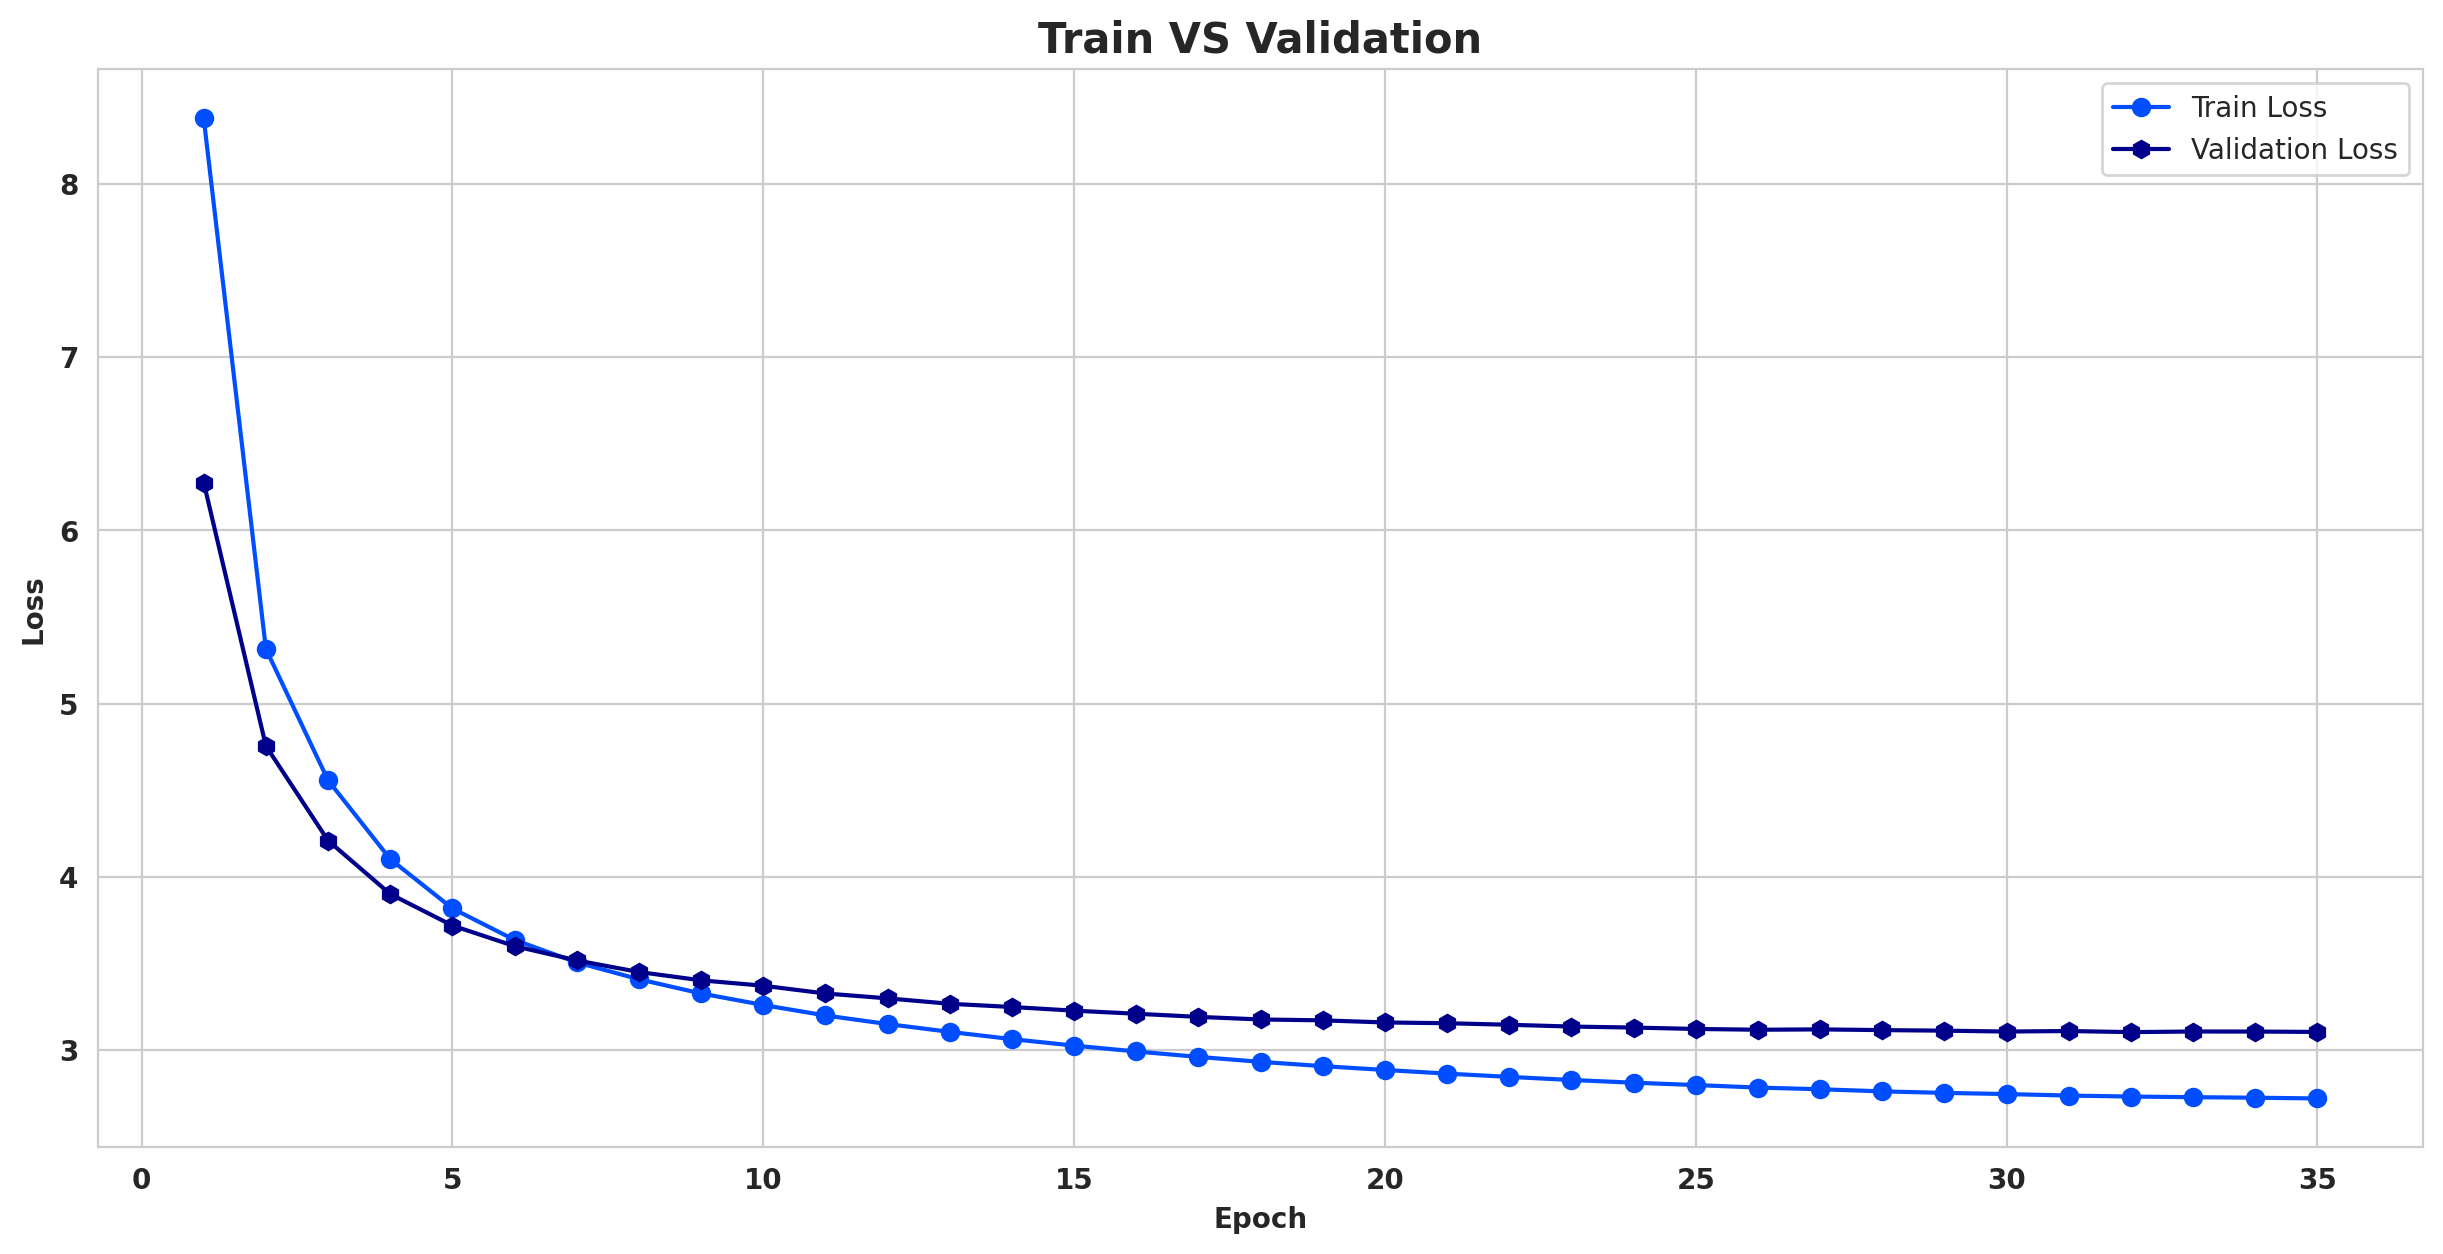

In [49]:
plt.figure(figsize=(15, 7), dpi=200)
sns.set_style('whitegrid')
plt.plot([x+1 for x in range(len(history.history['loss']))], history.history['loss'], color='#004EFF', marker='o')
plt.plot([x+1 for x in range(len(history.history['loss']))], history.history['val_loss'], color='#00008B', marker='h')
plt.title('Train VS Validation', fontsize=15, fontweight='bold')
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.xlabel('Epoch', fontweight='bold')
plt.ylabel('Loss', fontweight='bold')
plt.legend(['Train Loss', 'Validation Loss'], loc='best')
plt.show()

# Inference
> ##### **Caption Generation:** At **each time step**, **the decoder takes** as input **the embedded image features** along with **the decoded captions** (starting with <start\> at the first time step), **predicting the probabilities** of **the next word**.
> ##### **Greedy algorithm:** To select  **the best caption**, **the greedy algorithm** is employed. This method, chooses **the most probable word** at each time step and **appends it** to the decoded captions **until** the selected word is the **<end\>** token, **or the length** of the decoded captions exceeds  **the maximum sequence length**.
> ##### **Evaluation** is performed using the **BLEU score**
> ##### **Visualization:** The function visualization() plots the **images along with their corresponding actual and predicted captions, accompanied by 4 BLEU scores**.

In [51]:
vocab = vectorization.get_vocabulary()
INDEX_TO_WORD = {idx: word for idx, word in enumerate(vocab)}
MAX_DECODED_SENTENCE_LENGTH = SEQ_LENGTH - 1
test_images = list(test_data.keys())

def greedy_algorithm(image):
    # Read the image from the disk
    image = decode_and_resize(image)

    # Pass the image to the CNN
    image = tf.expand_dims(image, 0)
    image = caption_model.cnn_model(image)

    # Pass the image features to the Transformer encoder
    encoded_img = caption_model.encoder(image, training=False)

    # Generate the caption using the Transformer decoder
    decoded_caption = "<start> "
    for i in range(MAX_DECODED_SENTENCE_LENGTH):
        tokenized_caption = vectorization([decoded_caption])[:, :-1]
        mask = tf.math.not_equal(tokenized_caption, 0)
        predictions = caption_model.decoder(tokenized_caption, encoded_img, training=False, mask=mask)
        sampled_token_index = np.argmax(predictions[0, i, :])
        sampled_token = INDEX_TO_WORD[sampled_token_index]
        if sampled_token == "<end>":
            break
        decoded_caption += " " + sampled_token

    decoded_caption = decoded_caption.replace("<start> ", "")
    decoded_caption = decoded_caption.replace(" <end>", "").strip()
    
    return decoded_caption

In [52]:
# Generating captions
generated_captions = {}

pbar = tqdm_notebook(total=len(test_data), position=0, leave=True, colour='green')
for image_id in test_data:
    cap = greedy_algorithm(image_id)
    generated_captions[image_id] = cap
    pbar.update(1)
    
pbar.close()

  0%|          | 0/162 [00:00<?, ?it/s]

In [53]:
# Calculates BLEU score of predictions
def BLEU_score(actual, predicted):
    # Standardizing the actual captions
    processed_actual = []
    for i in actual:
        cap = [INDEX_TO_WORD[x] for x in vectorization(i).numpy() if INDEX_TO_WORD[x] != '']
        cap = ' '.join(cap)
        processed_actual.append(cap)
    
    # Calculating the BLEU score by comparing the predicted caption with five actual captions.
    b1=corpus_bleu(processed_actual, predicted, weights=(1.0, 0, 0, 0))
    b2=corpus_bleu(processed_actual, predicted, weights=(0.5, 0.5, 0, 0))
    b3=corpus_bleu(processed_actual, predicted, weights=(0.3, 0.3, 0.3, 0))
    b4=corpus_bleu(processed_actual, predicted, weights=(0.25, 0.25, 0.25, 0.25))
    
    return [
        (f'BLEU-4: {round(b4, 5)}'),
        (f'BLEU-3: {round(b3, 5)}'),
        (f'BLEU-2: {round(b2, 5)}'),
        (f'BLEU-1: {round(b1, 5)}'),
        (f'Generated Caption: {predicted[0]}'),
    ]

### Visualizing some of the **test images** along with their corresponding **generated captions**

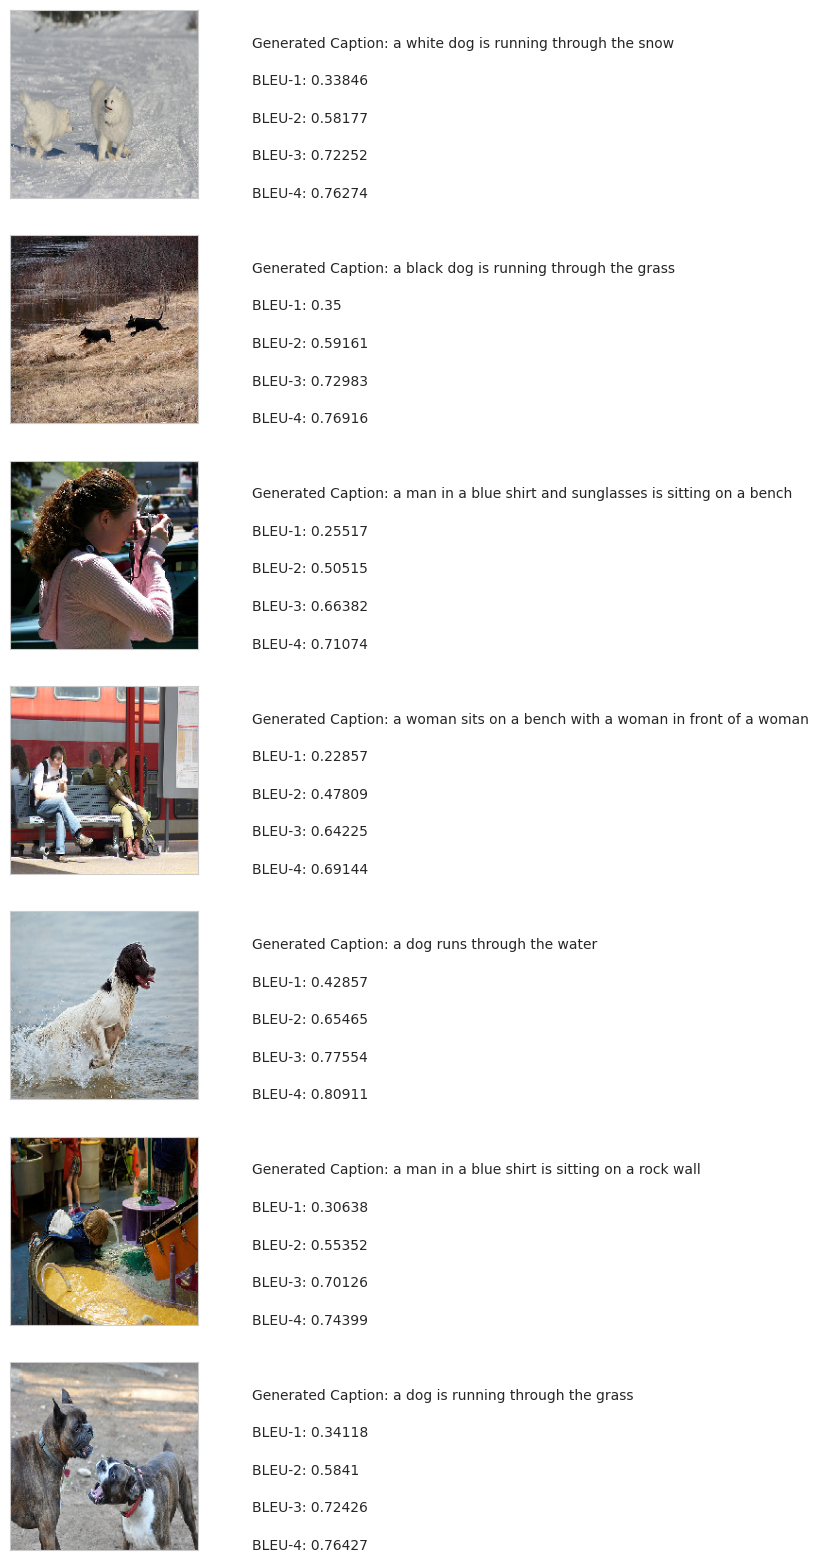

In [54]:
def visualization(data, generated_captions, evaluator, num_of_images):
    keys = list(data.keys()) # List of all test images
    images = [np.random.choice(keys) for i in range(num_of_images)] # Randomly selected images
    
    count = 1
    fig = plt.figure(figsize=(6,20))    
    for filename in images:
        actual_cap = data[filename]
        actual_cap = [x.replace("<start> ", "") for x in actual_cap] # Removing the start token
        actual_cap = [x.replace(" <end>", "") for x in actual_cap] # Removing the end token
        
        caption = generated_captions[filename]
        # Getting the bleu score
        caps_with_score = evaluator(actual_cap, [caption]*(len(actual_cap)))
    
        image_load = load_img(filename, target_size=(199,199,3))
        ax = fig.add_subplot(num_of_images,2,count,xticks=[],yticks=[])
        ax.imshow(image_load)
        count += 1

        ax = fig.add_subplot(num_of_images,2,count)
        plt.axis('off')
        ax.plot()
        ax.set_xlim(0,1)
        ax.set_ylim(0,len(caps_with_score))
        for i, text in enumerate(caps_with_score):
            ax.text(0,i,text,fontsize=10)
        count += 1
    plt.show()
    
visualization(test_data, generated_captions, BLEU_score, 7)

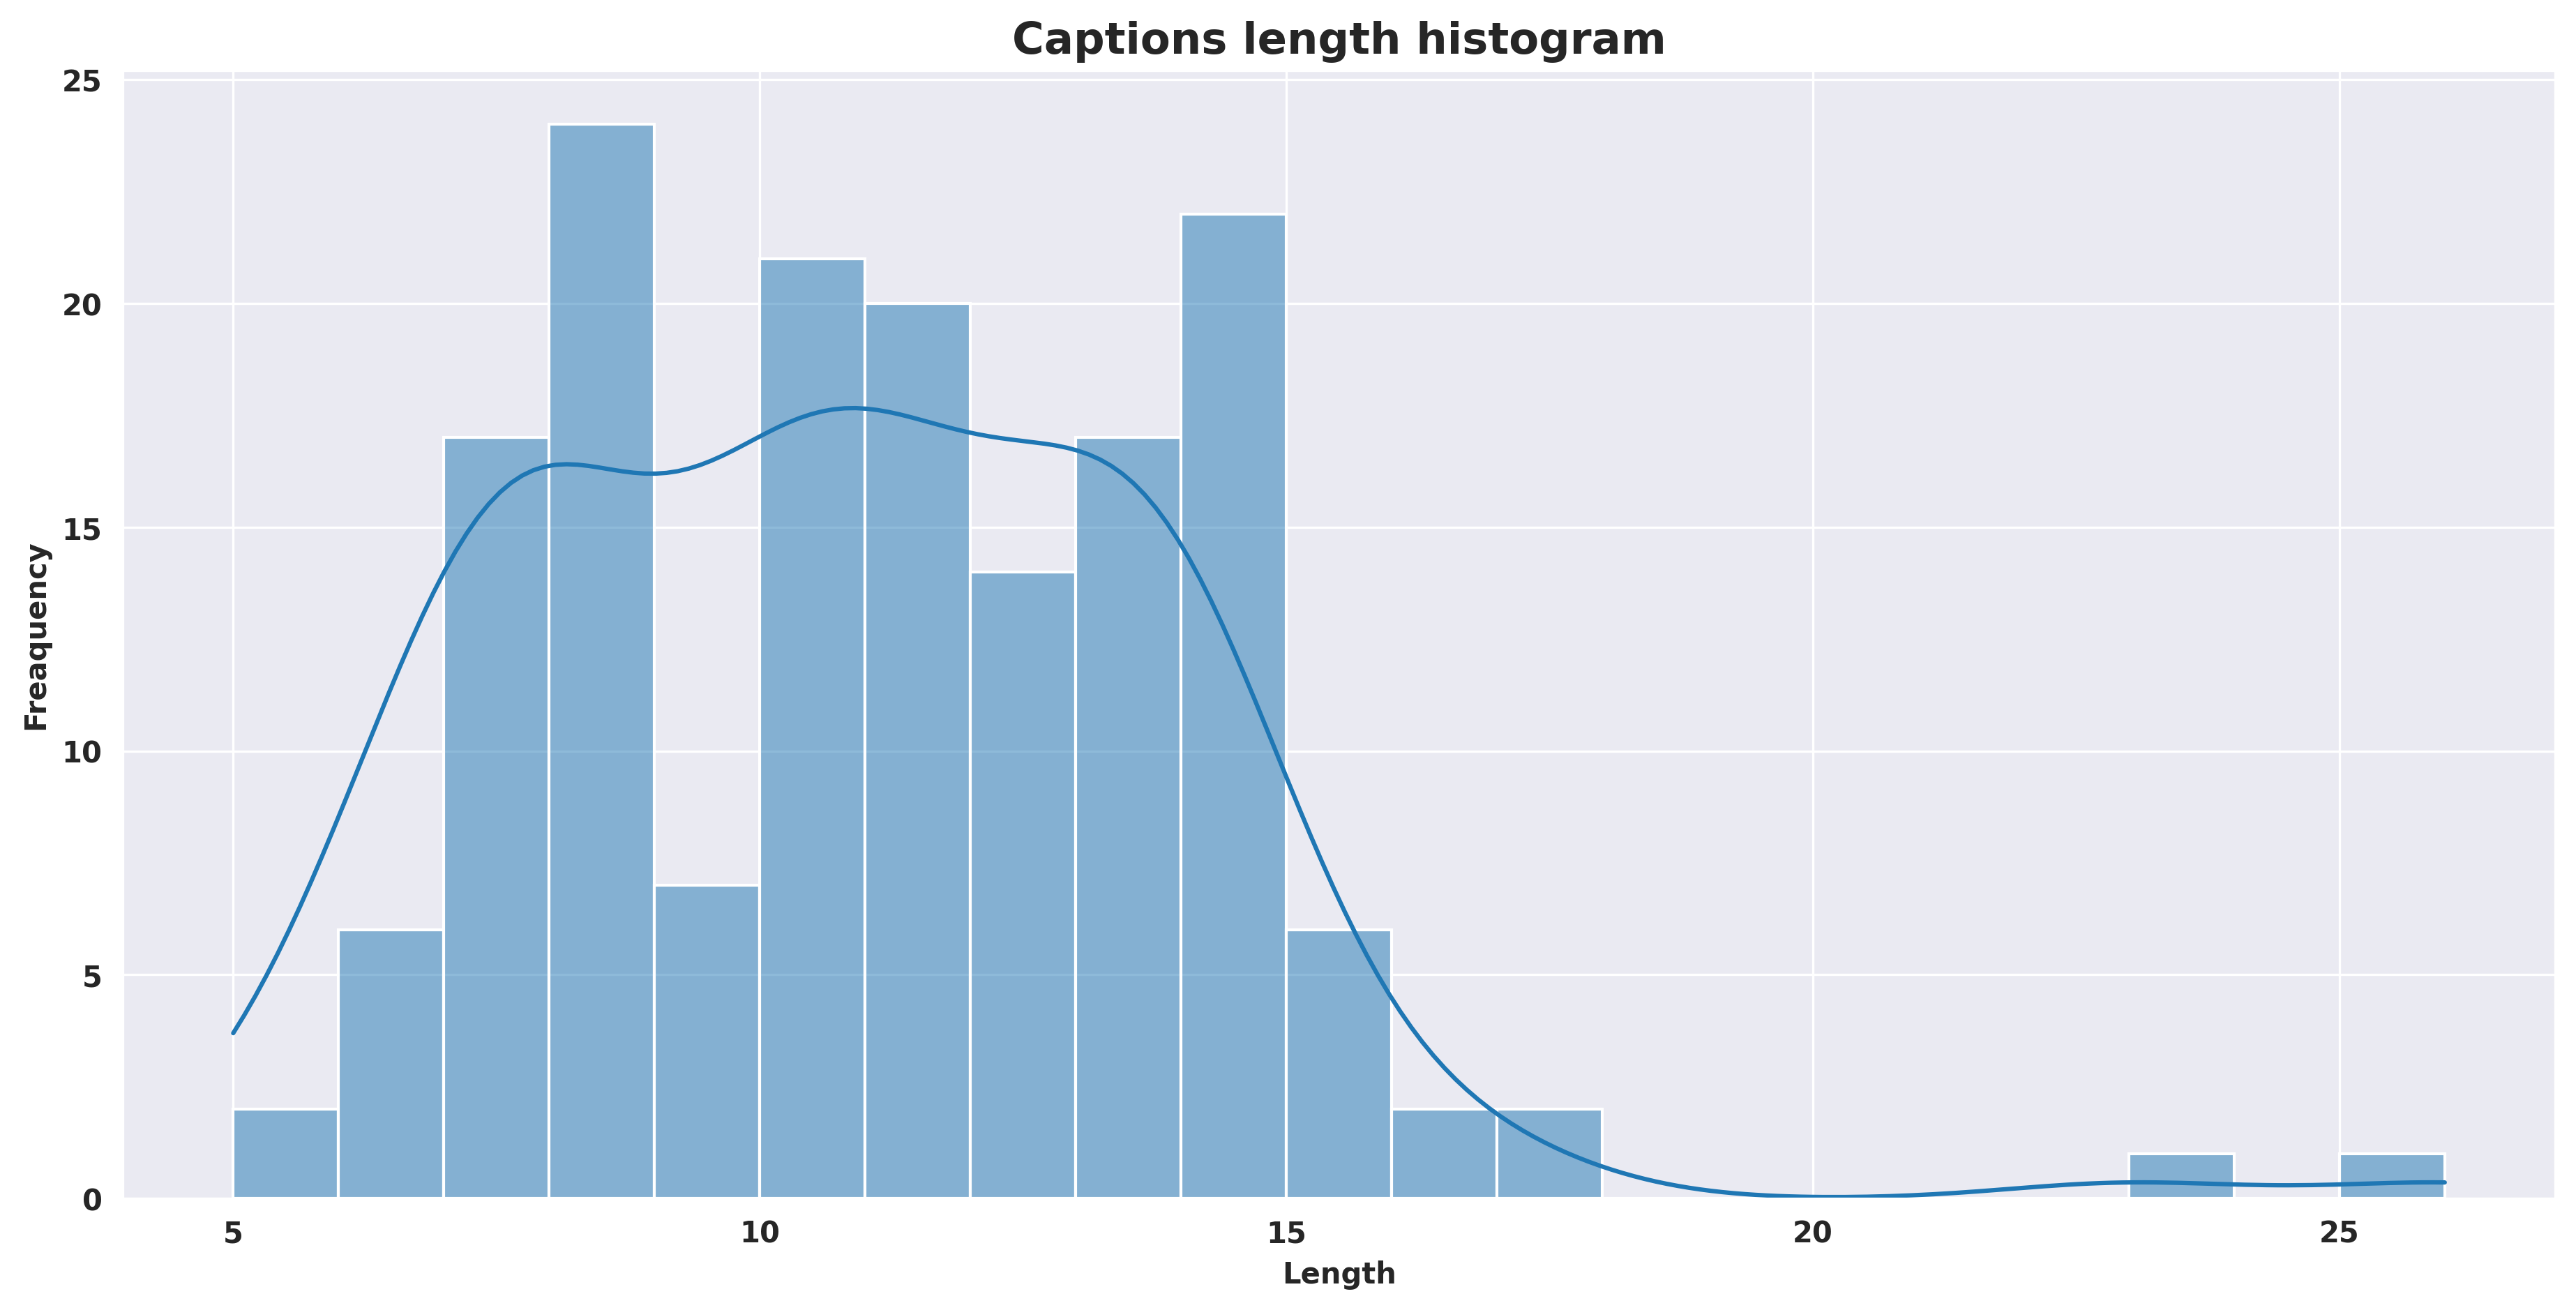

In [55]:
captions_length(list(generated_captions.values()))

In [56]:
word_occurrences(list(generated_captions.values()))

In [60]:
# Flatten captions for evaluation
test_captions_list = []
for img_path, caps in test_data.items():
    for cap in caps:
        # Store in format "image_path \t caption"
        test_captions_list.append(f"{img_path}\t{cap}")


In [61]:
from tqdm import tqdm
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import numpy as np
import tensorflow as tf

# -------------------------------
# 🔧 Beam search configuration
# -------------------------------
BEAM_WIDTH = 3
LENGTH_PENALTY_ALPHA = 0.7


# -------------------------------
# 1️⃣ Transformer Greedy caption
# -------------------------------
def greedy_transformer_caption(image_path):
    """
    Generate caption for a single test image using Transformer (Greedy)
    """
    # 1. Load and preprocess image
    image = decode_and_resize(image_path)
    image = tf.expand_dims(image, 0)

    # 2. CNN features
    cnn_features = caption_model.cnn_model(image)

    # 3. Encoder output
    encoded_img = caption_model.encoder(cnn_features, training=False)

    # 4. Caption generation (Greedy)
    decoded_caption = "<start> "

    for i in range(MAX_DECODED_SENTENCE_LENGTH):
        tokenized_caption = vectorization([decoded_caption])[:, :-1]
        mask = tf.math.not_equal(tokenized_caption, 0)

        predictions = caption_model.decoder(
            tokenized_caption,
            encoded_img,
            training=False,
            mask=mask
        )

        sampled_token_index = np.argmax(predictions[0, i, :])
        sampled_token = INDEX_TO_WORD[sampled_token_index]

        if sampled_token == "<end>":
            break

        decoded_caption += " " + sampled_token

    decoded_caption = decoded_caption.replace("<start> ", "").replace(" <end>", "").strip()
    return decoded_caption


# -------------------------------
# 2️⃣ Transformer Beam Search (Beam = 3)
# -------------------------------
def beam_transformer_caption(image_path, K_beams=3, alpha=0.7):
    """
    Generate caption using Transformer with Beam Search (beam width = 3)
    """
    # 1. Load image
    image = decode_and_resize(image_path)
    image = tf.expand_dims(image, 0)

    # 2. CNN + Encoder
    cnn_features = caption_model.cnn_model(image)
    encoded_img = caption_model.encoder(cnn_features, training=False)

    # 3. Initialize beam
    sequences = [("<start>", 0.0)]  # (sequence, log_prob)

    # 4. Beam decoding loop
    for t in range(MAX_DECODED_SENTENCE_LENGTH):
        all_candidates = []

        for seq, score in sequences:
            tokenized_caption = vectorization([seq])[:, :-1]
            mask = tf.math.not_equal(tokenized_caption, 0)

            preds = caption_model.decoder(
                tokenized_caption,
                encoded_img,
                training=False,
                mask=mask
            )

            preds_step = preds[0, t, :]

            # Top-K tokens
            top_indices = np.argsort(preds_step.numpy())[-K_beams:]

            for idx in top_indices:
                token = INDEX_TO_WORD[idx]
                new_seq = seq + " " + token
                new_score = score + np.log(preds_step[idx] + 1e-9)
                all_candidates.append((new_seq, new_score))

        # Keep top K sequences with length penalty
        sequences = sorted(
            all_candidates,
            key=lambda x: x[1] / (len(x[0].split()) ** alpha),
            reverse=True
        )[:K_beams]

    best_caption = sequences[0][0]
    best_caption = best_caption.replace("<start> ", "").replace(" <end>", "").strip()

    return best_caption

def evaluate_transformer_test_set(K_beams=BEAM_WIDTH, alpha=LENGTH_PENALTY_ALPHA):
    from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
    smoothie = SmoothingFunction().method4

    bleu_scores_greedy, bleu_scores_beam = [], []

    for img_id in tqdm(test_data.keys(), desc="Test Images"):
        greedy_cap = greedy_transformer_caption(img_id)
        beam_cap = beam_transformer_caption(img_id, K_beams=K_beams, alpha=alpha)

        ground_truth_caps = [
            cap.split('\t')[1].lower().split()
            for cap in test_captions_list
            if cap.startswith(img_id + "\t")
        ]

        greedy_tokens = greedy_cap.lower().split()
        beam_tokens = beam_cap.lower().split()

        # BLEU 1-4
        bleu_g = [
            sentence_bleu(ground_truth_caps, greedy_tokens, weights=w, smoothing_function=smoothie)
            for w in [(1,0,0,0),(0.5,0.5,0,0),(0.33,0.33,0.33,0),(0.25,0.25,0.25,0.25)]
        ]
        bleu_b = [
            sentence_bleu(ground_truth_caps, beam_tokens, weights=w, smoothing_function=smoothie)
            for w in [(1,0,0,0),(0.5,0.5,0,0),(0.33,0.33,0.33,0),(0.25,0.25,0.25,0.25)]
        ]

        bleu_scores_greedy.append(bleu_g)
        bleu_scores_beam.append(bleu_b)

    avg_greedy = np.mean(np.array(bleu_scores_greedy), axis=0)
    avg_beam = np.mean(np.array(bleu_scores_beam), axis=0)

    print("\n====== AVERAGE BLEU SCORES ON TEST SET ======")
    print("Greedy: BLEU-1 {:.4f}, BLEU-2 {:.4f}, BLEU-3 {:.4f}, BLEU-4 {:.4f}".format(*avg_greedy))
    print("Beam:   BLEU-1 {:.4f}, BLEU-2 {:.4f}, BLEU-3 {:.4f}, BLEU-4 {:.4f}".format(*avg_beam))

    return avg_greedy, avg_beam


In [63]:
# -------------------------------
# ✅ Run evaluation (Beam = 3)
# -------------------------------
avg_greedy_transformer, avg_beam_transformer = evaluate_transformer_test_set(
    K_beams=3,
    alpha=0.7
)


Test Images: 100%|██████████| 162/162 [10:11<00:00,  3.77s/it]


====== AVERAGE BLEU SCORES ON TEST SET ======
Greedy: BLEU-1 0.5256, BLEU-2 0.3698, BLEU-3 0.3095, BLEU-4 0.2681
Beam:   BLEU-1 0.5525, BLEU-2 0.4041, BLEU-3 0.3376, BLEU-4 0.2888


In [62]:
!pip install pycocoevalcap rouge-score


In [66]:
from pycocoevalcap.cider.cider import Cider
from rouge_score import rouge_scorer

def evaluate_cider_rouge():
    cider = Cider()
    rouge = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

    gts = {}
    res = {}

    for i, img in enumerate(test_data.keys()):
        pred = beam_transformer_caption(img, K_beams=5)

        gts[i] = [cap.lower() for cap in test_data[img]]
        res[i] = [pred.lower()]

    cider_score, _ = cider.compute_score(gts, res)

    rouge_scores = []
    for i in gts:
        score = rouge.score(res[i][0], gts[i][0])['rougeL'].fmeasure
        rouge_scores.append(score)

    print("\n====== CIDEr / ROUGE-L ======")
    print(f"CIDEr:   {cider_score:.4f}")
    print(f"ROUGE-L: {np.mean(rouge_scores):.4f}")

    return cider_score, np.mean(rouge_scores)


In [67]:
from nltk.translate.bleu_score import sentence_bleu
import tensorflow as tf
import numpy as np
from PIL import Image

# ---------------------------
# Helper: Load & preprocess image
# ---
image_path = "/kaggle/input/flickr30k/images/1000268201.jpg"
def load_and_preprocess_image(image_path):
    img = Image.open(image_path).convert("RGB")
    img = img.resize(IMAGE_SIZE)
    img = np.array(img) / 255.0
    img = tf.convert_to_tensor(img, dtype=tf.float32)
    img = tf.expand_dims(img, 0)  # Add batch dimension
    return img

# ---------------------------
# Greedy caption generator
# ---------------------------
def greedy_caption_transformer(image_path):
    image = load_and_preprocess_image(image_path)
    
    # CNN features
    cnn_features = caption_model.cnn_model(image)
    
    # Encoder
    encoded_image = caption_model.encoder(cnn_features, training=False)
    
    # Initialize caption
    caption = "<start>"
    for i in range(MAX_DECODED_SENTENCE_LENGTH):
        tokenized = vectorization([caption])[:, :-1]
        mask = tf.math.not_equal(tokenized, 0)
        
        preds = caption_model.decoder(tokenized, encoded_image, training=False, mask=mask)
        next_token_idx = np.argmax(preds[0, i, :])
        next_word = INDEX_TO_WORD[next_token_idx]
        
        if next_word == "<end>":
            break
        caption += " " + next_word
    
    # Clean caption
    caption = caption.replace("<start> ", "").strip()
    return caption

# ---------------------------
# Test with one image
# ---------------------------
test_image = list(test_data.keys())[0]  # pick first test image
print("Test image:", test_image)

# Ground truth captions
gt_captions = [cap.replace("<start> ", "").replace(" <end>", "").strip()
               for cap in test_data[test_image]]

# Generate caption
generated_caption = greedy_caption_transformer(test_image)
print("\nGenerated caption (Greedy):", generated_caption)

# Compute BLEU scores
bleu1 = np.mean([sentence_bleu([gt.split()], generated_caption.split(), weights=(1, 0, 0, 0)) for gt in gt_captions])
bleu2 = np.mean([sentence_bleu([gt.split()], generated_caption.split(), weights=(0.5, 0.5, 0, 0)) for gt in gt_captions])
bleu3 = np.mean([sentence_bleu([gt.split()], generated_caption.split(), weights=(0.33, 0.33, 0.33, 0)) for gt in gt_captions])
bleu4 = np.mean([sentence_bleu([gt.split()], generated_caption.split(), weights=(0.25, 0.25, 0.25, 0.25)) for gt in gt_captions])

print(f"\nBLEU Scores:\nBLEU-1: {bleu1:.4f}, BLEU-2: {bleu2:.4f}, BLEU-3: {bleu3:.4f}, BLEU-4: {bleu4:.4f}")


Test image: /kaggle/input/flickr8k/Images/459778335_857d8ffebf.jpg

Generated caption (Greedy): a black bird is flying through the air

BLEU Scores:
BLEU-1: 0.1359, BLEU-2: 0.1430, BLEU-3: 0.2037, BLEU-4: 0.2420


In [ ]:
!pip install pycocoevalcap

In [68]:
from pycocoevalcap.cider.cider import Cider


In [70]:
def evaluate_cider_on_test(test_data, use_beam=False, K_beams=3):
    """
    test_data: dict -> {img_path: [gt_caption1, gt_caption2, ...]}
    use_beam: False = greedy, True = beam search
    """

    gts = {}  # ground truth captions
    res = {}  # predicted captions

    for i, (img_path, caps) in enumerate(tqdm(test_data.items(), desc="Evaluating CIDEr")):
        img_id = str(i)

        # Ground Truths (list of captions)
        gts[img_id] = caps

        # Prediction (single caption)
        if use_beam:
            pred_caption = beam_transformer_caption(img_path, K_beams=K_beams)
        else:
            pred_caption = greedy_transformer_caption(img_path)

        # Must be list
        res[img_id] = [pred_caption]

    cider_scorer = Cider()
    cider_score, per_image_scores = cider_scorer.compute_score(gts, res)

    return cider_score


In [72]:
cider_greedy = evaluate_cider_on_test(test_data, use_beam=False)
print("✅ CIDEr (Greedy):", round(cider_greedy, 4))


Evaluating CIDEr: 100%|██████████| 162/162 [01:37<00:00,  1.66it/s]

✅ CIDEr (Greedy): 0.3511


In [73]:
def beam_transformer_caption(image_path, K_beams=3, alpha=0.7, max_len=MAX_DECODED_SENTENCE_LENGTH):
    """
    Generate caption using Transformer with Beam Search and length penalty
    """
    # 1️⃣ Load and preprocess image
    image = decode_and_resize(image_path)  # your preprocessing function
    image = tf.expand_dims(image, 0)

    # 2️⃣ CNN + Transformer encoder
    cnn_features = caption_model.cnn_model(image)
    encoded_img = caption_model.encoder(cnn_features, training=False)

    # 3️⃣ Initialize beams: list of [caption_so_far, cumulative_log_prob]
    sequences = [["<start>", 0.0]]

    for t in range(max_len):
        all_candidates = []
        for seq, score in sequences:
            # If last token is <end>, keep the sequence as-is
            if seq.split()[-1] == "<end>":
                all_candidates.append([seq, score])
                continue

            # Tokenize current sequence
            tokenized_caption = vectorization([seq])[:, :-1]
            mask = tf.math.not_equal(tokenized_caption, 0)

            # Decoder prediction
            preds = caption_model.decoder(tokenized_caption, encoded_img, training=False, mask=mask)
            preds_step = preds[0, t, :]  # probabilities for current step

            # Top K candidates
            top_indices = preds_step.numpy().argsort()[-K_beams:][::-1]
            for idx in top_indices:
                token = INDEX_TO_WORD[idx]
                candidate_seq = seq + " " + token
                candidate_score = score + np.log(preds_step[idx] + 1e-9)
                all_candidates.append([candidate_seq, candidate_score])

        # Keep top K sequences with length penalty
        sequences = sorted(
            all_candidates,
            key=lambda x: x[1] / (len(x[0].split())**alpha),
            reverse=True
        )[:K_beams]

        # Stop if all sequences have <end>
        if all(seq[0].split()[-1] == "<end>" for seq in sequences):
            break

    # 4️⃣ Return best sequence
    best_caption = sequences[0][0].replace("<start> ", "").replace(" <end>", "").strip()
    return best_caption


In [74]:
cider_beam = evaluate_cider_on_test(test_data, use_beam=True, K_beams=3)
print("✅ CIDEr (Beam):", round(cider_beam, 4))


Evaluating CIDEr: 100%|██████████| 162/162 [04:18<00:00,  1.59s/it]

✅ CIDEr (Beam): 0.37


In [ ]:
!pip install pycocoevalcap rouge-score


In [76]:
from pycocoevalcap.cider.cider import Cider
from rouge_score import rouge_scorer
from tqdm import tqdm
import numpy as np


In [77]:
from rouge_score import rouge_scorer
import numpy as np
from tqdm import tqdm

def evaluate_rouge_on_test(test_data, use_beam=False, K_beams=3):
    """
    test_data: dict -> {img_path: [gt_caption1, gt_caption2, ...]}
    use_beam: False -> greedy caption, True -> beam caption
    Returns: average ROUGE-1, ROUGE-2, ROUGE-L (F1)
    """

    scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

    rouge1_list, rouge2_list, rougeL_list = [], [], []

    for img_path, gt_caps in tqdm(test_data.items(), desc="Evaluating ROUGE"):
        
        # prediction caption
        if use_beam:
            pred_caption = beam_transformer_caption(img_path, K_beams=K_beams)
        else:
            pred_caption = greedy_transformer_caption(img_path)

        # take BEST ROUGE among all references
        best_r1, best_r2, best_rl = 0.0, 0.0, 0.0

        for ref in gt_caps:
            scores = scorer.score(ref, pred_caption)
            best_r1 = max(best_r1, scores["rouge1"].fmeasure)
            best_r2 = max(best_r2, scores["rouge2"].fmeasure)
            best_rl = max(best_rl, scores["rougeL"].fmeasure)

        rouge1_list.append(best_r1)
        rouge2_list.append(best_r2)
        rougeL_list.append(best_rl)

    return {
        "ROUGE-1": float(np.mean(rouge1_list)),
        "ROUGE-2": float(np.mean(rouge2_list)),
        "ROUGE-L": float(np.mean(rougeL_list)),
    }


In [78]:
rouge_greedy = evaluate_rouge_on_test(test_data, use_beam=False)
print("ROUGE (Greedy):", rouge_greedy)


Evaluating ROUGE: 100%|██████████| 162/162 [01:39<00:00,  1.63it/s]

ROUGE (Greedy): {'ROUGE-1': 0.430949707904216, 'ROUGE-2': 0.19842755844709714, 'ROUGE-L': 0.40030183367159017}


In [79]:
rouge_beam = evaluate_rouge_on_test(test_data, use_beam=True, K_beams=3)
print("ROUGE (Beam):", rouge_beam)


Evaluating ROUGE: 100%|██████████| 162/162 [04:13<00:00,  1.57s/it]

ROUGE (Beam): {'ROUGE-1': 0.4395813808361262, 'ROUGE-2': 0.2129828576127974, 'ROUGE-L': 0.4107138464515942}


In [ ]:
!pip install -U nltk


In [ ]:
import nltk
nltk.download("wordnet")
nltk.download("omw-1.4")


In [ ]:
# Clone coco-caption (SPICE lives here)
!git clone https://github.com/tylin/coco-caption.git


In [ ]:
import sys
sys.path.append("coco-caption")

from pycocoevalcap.spice.spice import Spice


In [ ]:
def evaluate_spice_on_test(test_data, use_beam=False, K_beams=3):
    """
    test_data: dict -> {img_path: [gt_caption1, gt_caption2, ...]}
    use_beam: False -> greedy caption, True -> beam caption
    Returns: average SPICE score
    """

    spice = Spice()
    spice_scores = []

    for img_path, gt_caps in tqdm(test_data.items(), desc="Evaluating SPICE"):

        # Prediction
        if use_beam:
            pred_caption = beam_transformer_caption(img_path, K_beams=K_beams)
        else:
            pred_caption = greedy_transformer_caption(img_path)

        # Format required by SPICE
        gts = {0: gt_caps}
        res = {0: [pred_caption]}

        score, _ = spice.compute_score(gts, res)
        spice_scores.append(score)

    return float(np.mean(spice_scores))


In [ ]:
import random
import numpy as np
from tqdm import tqdm

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from pycocoevalcap.cider.cider import Cider
from rouge_score import rouge_scorer


In [ ]:
smoothie = SmoothingFunction().method4

def compute_bleu_scores(references, hypothesis):
    """
    references: list[str]
    hypothesis: str
    """
    refs_tokens = [r.split() for r in references]
    hyp_tokens = hypothesis.split()

    bleu_scores = {
        "BLEU-1": sentence_bleu(refs_tokens, hyp_tokens, weights=(1,0,0,0), smoothing_function=smoothie),
        "BLEU-2": sentence_bleu(refs_tokens, hyp_tokens, weights=(0.5,0.5,0,0), smoothing_function=smoothie),
        "BLEU-3": sentence_bleu(refs_tokens, hyp_tokens, weights=(0.33,0.33,0.33,0), smoothing_function=smoothie),
        "BLEU-4": sentence_bleu(refs_tokens, hyp_tokens, weights=(0.25,0.25,0.25,0.25), smoothing_function=smoothie),
    }
    return bleu_scores


In [ ]:
rouge_eval = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)

def compute_rouge_l(references, hypothesis):
    best_rl = 0.0
    for ref in references:
        score = rouge_eval.score(ref, hypothesis)["rougeL"].fmeasure
        best_rl = max(best_rl, score)
    return best_rl


In [ ]:
cider_scorer = Cider()

def compute_cider(references, hypothesis):
    """
    references: list[str]
    hypothesis: str
    """
    gts = {"0": references}
    res = {"0": [hypothesis]}
    cider_score, _ = cider_scorer.compute_score(gts, res)
    return cider_score


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from sklearn.utils.class_weight import compute_class_weight
import cv2

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Model
import cv2
import numpy as np

import os

# GPU Check
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

In [ ]:
!pip install mtcnn

In [ ]:

from mtcnn import MTCNN
import cv2
import numpy as np

detector = MTCNN()

def detect_faces(img_path):
    img = cv2.imread(img_path)
    if img is None:
        return []

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    faces = detector.detect_faces(img_rgb)

    face_list = []

    for face in faces:
        x, y, w, h = face['box']
        x, y = max(0, x), max(0, y)

        crop = img_rgb[y:y+h, x:x+w]
        if crop.size == 0:
            continue

        crop = cv2.resize(crop, (224, 224))
        face_list.append({
            "face": crop,
            "box": (x, y, w, h)
        })

    return face_list

In [10]:
def map_emotion_to_word(emotion):
    emotion = emotion.lower()

    mapping = {
        "angry": "angry",
        "disgust": "disgusted",
        "fear": "scared",
        "happy": "happy",
        "sad": "sad",
        "surprise": "surprised",
        "neutral": ""
    }

    return mapping.get(emotion, "")

In [11]:
def predict_multiple_emotions(img_path):
    faces = detect_faces(img_path)

    if len(faces) == 0:
        return []

    results = []

    for f in faces:
        emotion = predict_emotion(f["face"])
        results.append({
            "box": f["box"],
            "emotion": emotion
        })

    return results

In [12]:
def get_main_emotion(image_path):
    faces = predict_multiple_emotions(image_path)

    if len(faces) == 0:
        return ""

    # take first face (main subject)
    emotion = faces[0]["emotion"]

    return map_emotion_to_word(emotion)

In [13]:
def insert_emotion_into_caption(caption, emotion):
    if emotion == "":
        return caption

    words = caption.split()

    # Case 1: starts with article
    if len(words) > 2 and words[0] in ["a", "an", "the"]:
        words.insert(1, emotion)

    # Case 2: starts with noun directly
    else:
        words.insert(0, emotion)

    return " ".join(words)

In [14]:
def generate_emotional_caption(image_path, use_beam=True):

    # 1️⃣ Caption
    if use_beam:
        caption = beam_transformer_caption(image_path)
    else:
        caption = greedy_transformer_caption(image_path)

    # 2️⃣ Emotion
    emotion = get_main_emotion(image_path)

    # 3️⃣ Combine
    final_caption = insert_emotion_into_caption(caption, emotion)

    return final_caption

In [15]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import os
import re
from collections import Counter

from nltk.translate.bleu_score import corpus_bleu
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:

import tensorflow as tf
from tensorflow.keras import layers, Model, regularizers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# FIX: Added this specific import to solve NameError
from sklearn.utils import class_weight 
from sklearn.metrics import confusion_matrix, classification_report

# Constants
IMG_SIZE = 224
BATCH_SIZE = 64
NUM_CLASSES = 7
AUTOTUNE = tf.data.AUTOTUNE

# ==========================================
# 1. DATA PIPELINE
# ==========================================
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/kaggle/input/fer2013/train",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/kaggle/input/fer2013/test",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

emotion_labels = train_ds.class_names

# Stronger augmentation to fight overfitting
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

def prepare_data(ds, augment=False):
    ds = ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)

train_ds_processed = prepare_data(train_ds, augment=True)
val_ds_processed = prepare_data(val_ds, augment=False)




# ==========================================
# 2. CALCULATE CLASS WEIGHTS
# ==========================================

print("Calculating class weights...")
y_train_list = []
# We use the original train_ds to get labels before prefetching
for _, labels in train_ds:
    y_train_list.extend(np.argmax(labels.numpy(), axis=1))

weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_list),
    y=y_train_list
)
class_weight_dict = dict(enumerate(weights))
print(f"Class weights: {class_weight_dict}")
# ==========================================
# 3. MODEL ARCHITECTURE
# ==========================================
def build_emotion_model():
    base_model = EfficientNetB0(include_top=False, weights="imagenet", input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base_model.trainable = False 

    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    
    x = layers.Dense(512, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Activation('elu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x) 
    
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    model = Model(inputs=base_model.input, outputs=outputs)
    return model, base_model

model, base_model = build_emotion_model()



# ==========================================
# 4. TRAINING SETUP
# ==========================================
# ==========================================
callbacks = [
    tf.keras.callbacks.ModelCheckpoint("best_emotion_model.h5", save_best_only=True, monitor="val_accuracy"),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True)
]

# --- STAGE 1: Head Training ---
print("\n--- STAGE 1: Training the Head ---")
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), 
              loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1), 
              metrics=["accuracy"])

history1 = model.fit(train_ds_processed, validation_data=val_ds_processed, 
                    epochs=10, callbacks=callbacks, class_weight=class_weight_dict)

# --- STAGE 2: Fine-Tuning ---
print("\n--- STAGE 2: Fine-Tuning EfficientNet ---")
base_model.trainable = True
for layer in base_model.layers[:-100]: # Unfreeze top 100
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(5e-5), 
              loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1), 
              metrics=["accuracy"])

history2 = model.fit(train_ds_processed, validation_data=val_ds_processed, 
                    epochs=25, callbacks=callbacks, class_weight=class_weight_dict)

# ==========================================
# 5. FINAL SAVE
# ==========================================
model.save("final_emotion_model.h5")
print("Model saved successfully!")

Found 28709 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.
Calculating class weights...
Class weights: {0: 1.0266046844269623, 1: 9.406618610747051, 2: 1.0010460615781582, 3: 0.5684387684387684, 4: 0.8260394187886635, 5: 0.8491274770777877, 6: 1.293372978330405}
16705208/16705208 [==============================] - 0s 0us/step

--- STAGE 1: Training the Head ---
Epoch 1/10


2026-06-02 13:51:41.473941: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodel/block2b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


449/449 [==============================] - 424s 925ms/step - loss: 2.2057 - accuracy: 0.3251 - val_loss: 1.6629 - val_accuracy: 0.4521 - lr: 0.0010
Epoch 2/10
449/449 [==============================] - 415s 922ms/step - loss: 1.7569 - accuracy: 0.3979 - val_loss: 1.6214 - val_accuracy: 0.4692 - lr: 0.0010
Epoch 3/10
449/449 [==============================] - 422s 939ms/step - loss: 1.6936 - accuracy: 0.4244 - val_loss: 1.5725 - val_accuracy: 0.4908 - lr: 0.0010
Epoch 4/10
449/449 [==============================] - 419s 931ms/step - loss: 1.6594 - accuracy: 0.4406 - val_loss: 1.5816 - val_accuracy: 0.4873 - lr: 0.0010
Epoch 5/10
449/449 [==============================] - 422s 938ms/step - loss: 1.6514 - accuracy: 0.4404 - val_loss: 1.5659 - val_accuracy: 0.4936 - lr: 0.0010
Epoch 6/10
449/449 [==============================] - 417s 928ms/step - loss: 1.6375 - accuracy: 0.4486 - val_loss: 1.5516 - val_accuracy: 0.5103 - lr: 0.0010
Epoch 7/10
449/449 [==============================] - 416

2026-06-02 15:01:19.452415: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodel/block2b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


449/449 [==============================] - 450s 958ms/step - loss: 1.8059 - accuracy: 0.3924 - val_loss: 1.5923 - val_accuracy: 0.4990 - lr: 5.0000e-05
Epoch 2/25
449/449 [==============================] - 430s 955ms/step - loss: 1.5820 - accuracy: 0.4739 - val_loss: 1.5028 - val_accuracy: 0.5385 - lr: 5.0000e-05
Epoch 3/25
449/449 [==============================] - 428s 952ms/step - loss: 1.4259 - accuracy: 0.5505 - val_loss: 1.4114 - val_accuracy: 0.5867 - lr: 5.0000e-05
Epoch 5/25
449/449 [==============================] - 431s 959ms/step - loss: 1.3769 - accuracy: 0.5765 - val_loss: 1.3842 - val_accuracy: 0.5982 - lr: 5.0000e-05
Epoch 6/25
449/449 [==============================] - 437s 970ms/step - loss: 1.3423 - accuracy: 0.5927 - val_loss: 1.3570 - val_accuracy: 0.6105 - lr: 5.0000e-05
Epoch 7/25
449/449 [==============================] - 440s 977ms/step - loss: 1.3025 - accuracy: 0.6093 - val_loss: 1.3404 - val_accuracy: 0.6173 - lr: 5.0000e-05
Epoch 8/25
449/449 [=============

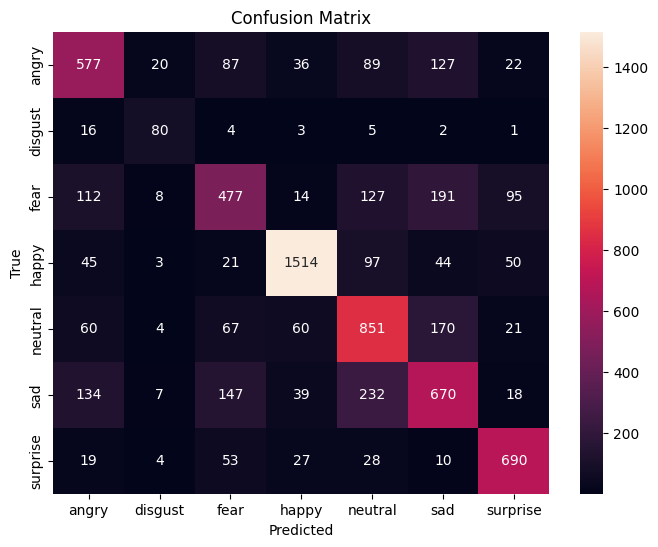

              precision    recall  f1-score   support

       angry       0.60      0.60      0.60       958
     disgust       0.63      0.72      0.68       111
        fear       0.56      0.47      0.51      1024
       happy       0.89      0.85      0.87      1774
     neutral       0.60      0.69      0.64      1233
         sad       0.55      0.54      0.54      1247
    surprise       0.77      0.83      0.80       831

    accuracy                           0.68      7178
   macro avg       0.66      0.67      0.66      7178
weighted avg       0.68      0.68      0.68      7178



In [17]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=emotion_labels,
            yticklabels=emotion_labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Report
print(classification_report(y_true, y_pred, target_names=emotion_labels))

In [18]:
def generate_emotional_caption(image_path, use_beam=True):

    # 1️⃣ Caption
    if use_beam:
        caption = beam_transformer_caption(image_path)
    else:
        caption = greedy_transformer_caption(image_path)

    # 2️⃣ Emotion
    emotion = get_main_emotion(image_path)

    # 3️⃣ Combine
    final_caption = insert_emotion_into_caption(caption, emotion)

    return final_caption

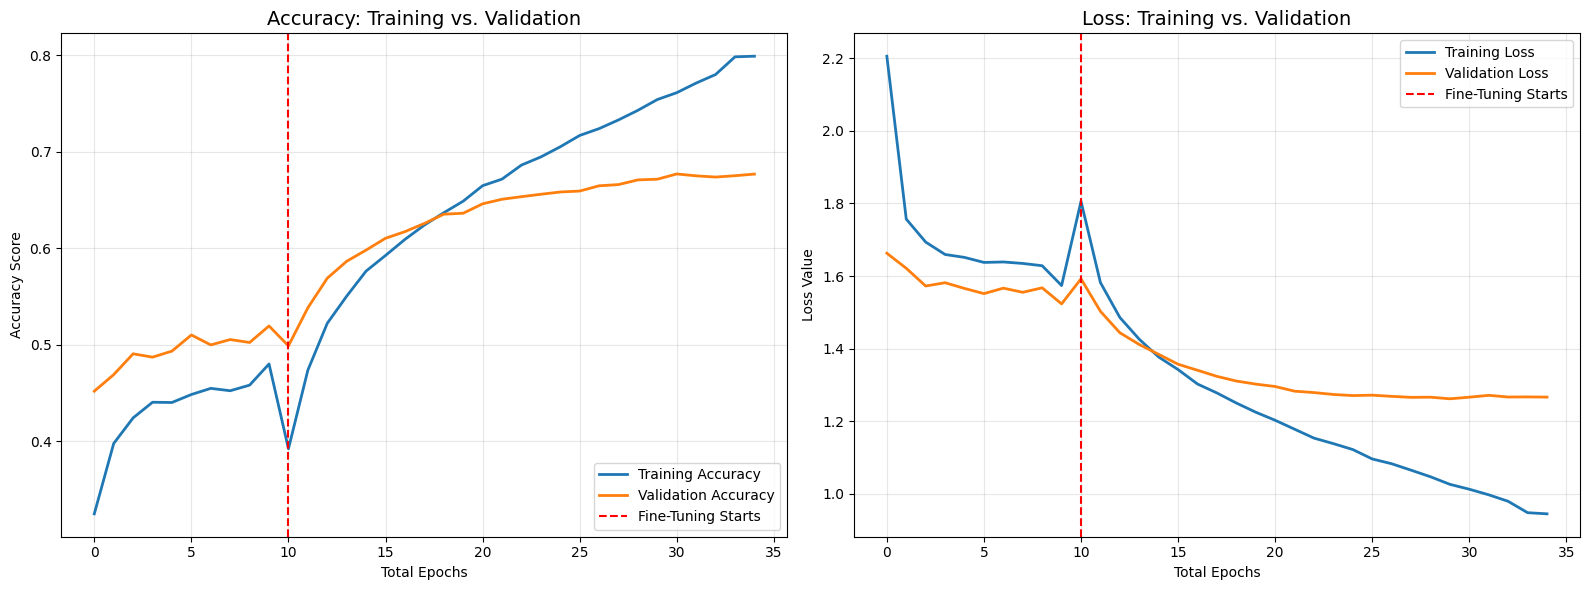

In [19]:
def plot_emotion_training(h1, h2):
    # 1. Combine metrics from both stages
    acc = h1.history['accuracy'] + h2.history['accuracy']
    val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss = h1.history['loss'] + h2.history['loss']
    val_loss = h1.history['val_loss'] + h2.history['val_loss']
    
    # Create the x-axis (epochs)
    epochs_range = range(len(acc))
    # Mark where Stage 2 (Fine-tuning) started
    stage2_start = len(h1.history['accuracy'])

    plt.figure(figsize=(16, 6))00
    

    # --- Plot 1: Accuracy ---
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', color='#1f77b4', lw=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='#ff7f0e', lw=2)
    plt.axvline(x=stage2_start, color='red', linestyle='--', label='Fine-Tuning Starts')
    plt.title('Accuracy: Training vs. Validation', fontsize=14)
    plt.xlabel('Total Epochs')
    plt.ylabel('Accuracy Score')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)

    # --- Plot 2: Loss ---
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', color='#1f77b4', lw=2)
    plt.plot(epochs_range, val_loss, label='Validation Loss', color='#ff7f0e', lw=2)
    plt.axvline(x=stage2_start, color='red', linestyle='--', label='Fine-Tuning Starts')
    plt.title('Loss: Training vs. Validation', fontsize=14)
    plt.xlabel('Total Epochs')
    plt.ylabel('Loss Value')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Run the plot function
plot_emotion_training(history1, history2)

In [81]:
def predict_multiple_emotions(img_path):
    faces = detect_faces(img_path)

    if len(faces) == 0:
        return []

    results = []

    for i, f in enumerate(faces):
        emotion = predict_emotion(f["face"])

        results.append({
            "face_id": f"Face {i+1}",
            "box": f["box"],
            "emotion": emotion
        })

    return results

In [82]:
def print_emotions(emotions):
    if len(emotions) == 0:
        print("No face detected")
        return

    for e in emotions:
        print(f"{e['face_id']}: {e['emotion']}")

In [101]:
import re

# ==========================================================
# Human-related words that can receive emotions
# ==========================================================

PERSON_WORDS = {
    "man", "men",
    "woman", "women",
    "boy", "boys",
    "girl", "girls",
    "person", "people",
    "child", "children",
    "kid", "kids",
    "baby", "babies",
    "guy", "guys",
    "lady", "ladies",
    "gentleman", "gentlemen",
    "couple",
    "group",
    "player", "players",
    "student", "students",
    "adult", "adults"
}


# ==========================================================
# Extract emotions from FER output
# ==========================================================

def extract_emotions(emotion_results):
    """
    Input:

    [
        {"face_id":"Face 1","emotion":"happy"},
        {"face_id":"Face 2","emotion":"sad"}
    ]

    Output:

    ["happy","sad"]
    """

    emotions = []

    for item in emotion_results:

        if "emotion" in item:
            emotions.append(item["emotion"].lower())

    return emotions


# ==========================================================
# Insert emotion before first human noun
# ==========================================================

def insert_emotion_before_person(caption, emotion):

    words = caption.split()

    for i, word in enumerate(words):

        clean_word = re.sub(r"[^\w]", "", word.lower())

        if clean_word in PERSON_WORDS:

            # avoid:
            # happy happy man
            if i > 0 and words[i-1].lower() == emotion:
                return caption

            words.insert(i, emotion)

            return " ".join(words)

    return caption


# ==========================================================
# Main Fusion Function
# ==========================================================

def fuse_caption_with_emotions(caption, emotion_results):

    emotions = extract_emotions(emotion_results)

    # ------------------------------------------------------
    # No faces detected
    # ------------------------------------------------------
    if len(emotions) == 0:
        return caption

    unique_emotions = list(set(emotions))

    # ------------------------------------------------------
    # One emotion only
    # ------------------------------------------------------
    if len(unique_emotions) == 1:

        emotion = unique_emotions[0]

        return insert_emotion_before_person(
            caption,
            emotion
        )

    # ------------------------------------------------------
    # Multiple different emotions
    # ------------------------------------------------------
    else:

        return caption + " showing different emotions"


# ==========================================================
# Complete Emotional Caption Generator
# ==========================================================

def generate_emotional_caption_v2(image_path,
                                  use_beam=True,
                                  K_beams=3):

    # ------------------------------------------------------
    # Generate caption
    # ------------------------------------------------------

    if use_beam:
        caption = beam_transformer_caption(
            image_path,
            K_beams=K_beams
        )
    else:
        caption = greedy_transformer_caption(
            image_path
        )

    # ------------------------------------------------------
    # Predict emotions
    # ------------------------------------------------------

    emotion_results = predict_multiple_emotions(
        image_path
    )

    # ------------------------------------------------------
    # Fuse
    # ------------------------------------------------------

    final_caption = fuse_caption_with_emotions(
        caption,
        emotion_results
    )

    return final_caption


# ==========================================================
# Dual Greedy + Beam Evaluation
# ==========================================================

def generate_emotional_captions_dual_v2(
        image_path,
        K_beams=3):

    # Greedy caption

    greedy_caption = greedy_transformer_caption(
        image_path
    )

    # Beam caption

    beam_caption = beam_transformer_caption(
        image_path,
        K_beams=K_beams
    )

    # FER

    emotion_results = predict_multiple_emotions(
        image_path
    )

    # Fusion

    greedy_final = fuse_caption_with_emotions(
        greedy_caption,
        emotion_results
    )

    beam_final = fuse_caption_with_emotions(
        beam_caption,
        emotion_results
    )

    emotions = extract_emotions(
        emotion_results
    )

    return {
        "greedy": greedy_final,
        "beam": beam_final,
        "emotions": emotions
    }

In [103]:
import cv2
import matplotlib.pyplot as plt

def test_unseen_image(img_path,
                      use_beam=True,
                      K_beams=3):

    # ==========================
    # Generate Caption
    # ==========================

    final_caption = generate_emotional_caption_v2(
        img_path,
        use_beam=use_beam,
        K_beams=K_beams
    )

    # ==========================
    # Detect Emotions
    # ==========================

    emotion_results = predict_multiple_emotions(img_path)

    emotions = extract_emotions(emotion_results)

    if len(emotions) == 0:
        emotion_text = "No face detected"
    else:
        emotion_text = ", ".join(emotions)

    # ==========================
    # Display Image
    # ==========================

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(7,7))
    plt.imshow(img)
    plt.axis("off")

    plt.title(
        f"Detected Emotions: {emotion_text}\n\n"
        f"Caption: {final_caption}",
        fontsize=10
    )

    plt.show()

    print("="*80)
    print("Image:", img_path)
    print("Emotions:", emotion_text)
    print("Final Caption:", final_caption)

    return {
        "image": img_path,
        "emotions": emotions,
        "caption": final_caption
    }

In [105]:
import random
import cv2
import matplotlib.pyplot as plt

def evaluate_emotional_captions_random_v2(
        test_data,
        num_images=10,
        seed=43,
        use_beam=True,
        K_beams=3):

    random.seed(seed)

    sample_imgs = random.sample(
        list(test_data.keys()),
        num_images
    )

    results = []

    for img_path in sample_imgs:

        # ==========================
        # Generate Caption
        # ==========================

        final_caption = generate_emotional_caption_v2(
            img_path,
            use_beam=use_beam,
            K_beams=K_beams
        )

        # ==========================
        # FER
        # ==========================

        emotion_results = predict_multiple_emotions(
            img_path
        )

        emotions = extract_emotions(
            emotion_results
        )

        emotion_text = (
            ", ".join(emotions)
            if emotions
            else "No face detected"
        )

        # ==========================
        # Display Image
        # ==========================

        img = cv2.imread(img_path)
        img = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2RGB
        )

        plt.figure(figsize=(7,7))
        plt.imshow(img)
        plt.axis("off")

        plt.title(
            f"Emotions: {emotion_text}\n\n"
            f"{final_caption}",
            fontsize=10
        )

        plt.show()

        print("="*80)
        print("Image:", img_path)
        print("Emotions:", emotion_text)
        print("Caption:", final_caption)

        results.append({
            "image": img_path,
            "emotions": emotions,
            "caption": final_caption
        })

    return results

In [110]:
results = evaluate_emotional_captions_random_v2(
    test_data,
    num_images=10,
    seed=43,
    use_beam=True,
    K_beams=3
)

NameError: name 'detect_faces' is not defined

In [111]:
import random
import re
import cv2
import matplotlib.pyplot as plt

# ==========================================================
# 1. HUMAN WORD LIST (for emotion placement)
# ==========================================================

PERSON_WORDS = {
    "man","men",
    "woman","women",
    "boy","boys",
    "girl","girls",
    "person","people",
    "child","children",
    "kid","kids",
    "baby","babies",
    "guy","guys",
    "lady","ladies",
    "gentleman","gentlemen",
    "couple",
    "group",
    "player","players",
    "student","students",
    "adult","adults"
}

# ==========================================================
# 2. IMAGE DISPLAY
# ==========================================================

def display_image(img_path, title=""):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(title)
    plt.show()

# ==========================================================
# 3. EMOTION EXTRACTION
# ==========================================================

def extract_emotions(emotion_results):
    """
    Convert:
    [{'emotion':'happy'}, {'emotion':'sad'}]
    -> ['happy','sad']
    """
    return [e["emotion"].lower() for e in emotion_results if "emotion" in e]

# ==========================================================
# 4. INSERT EMOTION INTO CAPTION (SMART FUSION)
# ==========================================================

def insert_emotion_before_person(caption, emotion):

    words = caption.split()

    for i, word in enumerate(words):

        clean = re.sub(r"[^\w]", "", word.lower())

        if clean in PERSON_WORDS:

            # avoid duplicates like "happy happy man"
            if i > 0 and words[i-1].lower() == emotion:
                return caption

            words.insert(i, emotion)
            return " ".join(words)

    return caption


def fuse_caption_with_emotions(caption, emotion_results):

    emotions = extract_emotions(emotion_results)

    # -------------------------
    # Case 1: no face detected
    # -------------------------
    if len(emotions) == 0:
        return caption

    unique_emotions = list(set(emotions))

    # -------------------------
    # Case 2: single emotion
    # -------------------------
    if len(unique_emotions) == 1:
        return insert_emotion_before_person(
            caption,
            unique_emotions[0]
        )

    # -------------------------
    # Case 3: multiple emotions
    # -------------------------
    return caption + " showing different emotions"

# ==========================================================
# 5. MAIN CAPTION GENERATOR
# ==========================================================

def generate_emotional_caption_v2(image_path,
                                  use_beam=True,
                                  K_beams=3):

    if use_beam:
        caption = beam_transformer_caption(
            image_path,
            K_beams=K_beams
        )
    else:
        caption = greedy_transformer_caption(image_path)

    emotion_results = predict_multiple_emotions(image_path)

    final_caption = fuse_caption_with_emotions(
        caption,
        emotion_results
    )

    return final_caption

# ==========================================================
# 6. SINGLE IMAGE TEST (UNSEEN IMAGE)
# ==========================================================

def test_unseen_image(img_path,
                      use_beam=True,
                      K_beams=3):

    final_caption = generate_emotional_caption_v2(
        img_path,
        use_beam=use_beam,
        K_beams=K_beams
    )

    emotion_results = predict_multiple_emotions(img_path)
    emotions = extract_emotions(emotion_results)

    emotion_text = ", ".join(emotions) if emotions else "No face detected"

    display_image(
        img_path,
        title=f"Emotions: {emotion_text}\nCaption: {final_caption}"
    )

    print("="*80)
    print("Image:", img_path)
    print("Emotions:", emotion_text)
    print("Caption:", final_caption)

    return {
        "image": img_path,
        "emotions": emotions,
        "caption": final_caption
    }

# ==========================================================
# 7. RANDOM TESTING ON DATASET (YOUR ORIGINAL STYLE)
# ==========================================================

def evaluate_emotional_captions_random_v2(
        test_data,
        num_images=10,
        seed=43,
        use_beam=True,
        K_beams=3):

    random.seed(seed)

    sample_imgs = random.sample(
        list(test_data.keys()),
        num_images
    )

    results = []

    for img_path in sample_imgs:

        # -------------------------
        # Generate caption
        # -------------------------
        final_caption = generate_emotional_caption_v2(
            img_path,
            use_beam=use_beam,
            K_beams=K_beams
        )

        # -------------------------
        # Emotions
        # -------------------------
        emotion_results = predict_multiple_emotions(img_path)
        emotions = extract_emotions(emotion_results)

        emotion_text = ", ".join(emotions) if emotions else "No face detected"

        # -------------------------
        # Display
        # -------------------------
        display_image(
            img_path,
            title=f"Emotion: {emotion_text}\nCaption: {final_caption}"
        )

        print("="*80)
        print("Image:", img_path)
        print("Emotion:", emotion_text)
        print("Caption:", final_caption)

        results.append({
            "image": img_path,
            "emotions": emotions,
            "final_caption": final_caption
        })

    return results

In [130]:
import random
import re
import cv2
import matplotlib.pyplot as plt

# ==========================================================
# 1. HUMAN WORDS
# ==========================================================

PERSON_WORDS = {
    "man","men","woman","women","boy","boys","girl","girls",
    "person","people","child","children","kid","kids",
    "baby","babies","guy","guys","lady","ladies",
    "gentleman","gentlemen","couple","group",
    "player","players","student","students","adult","adults"
}

# ==========================================================
# 2. DISPLAY IMAGE
# ==========================================================

def display_image(img_path, title=""):
    img = cv2.imread(img_path)

    if img is None:
        print("Image not found:", img_path)
        return

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(title)
    plt.show()

# ==========================================================
# 3. EMOTION EXTRACTION
# ==========================================================

def extract_emotions(emotion_results):
    return [
        e["emotion"].lower()
        for e in emotion_results
        if "emotion" in e
    ]

# ==========================================================
# 4. BASIC SINGLE EMOTION INSERTION
# ==========================================================

def insert_emotion(caption, emotion):

    words = caption.split()

    for i, w in enumerate(words):

        clean = re.sub(r"[^\w]", "", w.lower())

        if clean in PERSON_WORDS:

            if i > 0 and words[i-1].lower() == emotion:
                return caption

            words.insert(i, emotion)
            return " ".join(words)

    return caption

# ==========================================================
# 5. SMART MULTI-FACE FUSION (IMPORTANT PART)
# ==========================================================

def smart_fusion(caption, emotion_results):

    emotions = extract_emotions(emotion_results)

    # -------------------------
    # No face detected
    # -------------------------
    if len(emotions) == 0:
        return caption

    unique = list(set(emotions))

    # -------------------------
    # Single emotion
    # -------------------------
    if len(unique) == 1:
        return insert_emotion(caption, unique[0])

    # -------------------------
    # MULTI-FACE DIFFERENT EMOTIONS (KEY FIX)
    # -------------------------

    # Build explanation string
    emotion_pairs = []
    for i, e in enumerate(emotions):
        emotion_pairs.append(f"one {e}")

    explanation = " and ".join(emotion_pairs)

    return caption + f" showing different emotions ({explanation})"

# ==========================================================
# 6. CAPTION GENERATION
# ==========================================================

def generate_emotional_caption_v2(image_path,
                                  use_beam=True,
                                  K_beams=3):

    if use_beam:
        caption = beam_transformer_caption(
            image_path,
            K_beams=K_beams
        )
    else:
        caption = greedy_transformer_caption(image_path)

    emotion_results = predict_multiple_emotions(image_path)

    return smart_fusion(caption, emotion_results)

# ==========================================================
# 7. SINGLE IMAGE TEST
# ==========================================================

def test_unseen_image(img_path,
                      use_beam=True,
                      K_beams=3):

    final_caption = generate_emotional_caption_v2(
        img_path,
        use_beam=use_beam,
        K_beams=K_beams
    )

    emotion_results = predict_multiple_emotions(img_path)
    emotions = extract_emotions(emotion_results)

    emotion_text = ", ".join(emotions) if emotions else "No face detected"

    display_image(
        img_path,
        title=f"Emotions: {emotion_text}\nCaption: {final_caption}"
    )

    print("="*80)
    print("Image:", img_path)
    print("Emotions:", emotion_text)
    print("Caption:", final_caption)

    return {
        "image": img_path,
        "emotions": emotions,
        "caption": final_caption
    }

# ==========================================================
# 8. RANDOM DATASET EVALUATION
# ==========================================================

def evaluate_emotional_captions_random_v2(
        test_data,
        num_images=10,
        seed=43,
        use_beam=True,
        K_beams=3):

    random.seed(seed)

    sample_imgs = random.sample(
        list(test_data.keys()),
        num_images
    )

    results = []

    for img_path in sample_imgs:

        final_caption = generate_emotional_caption_v2(
            img_path,
            use_beam=use_beam,
            K_beams=K_beams
        )

        emotion_results = predict_multiple_emotions(img_path)
        emotions = extract_emotions(emotion_results)

        emotion_text = ", ".join(emotions) if emotions else "No face detected"

        display_image(
            img_path,
            title=f"Emotion: {emotion_text}\nCaption: {final_caption}"
        )

        print("="*80)
        print("Image:", img_path)
        print("Emotion:", emotion_text)
        print("Caption:", final_caption)

        results.append({
            "image": img_path,
            "emotions": emotions,
            "final_caption": final_caption
        })

    return results

In [118]:
from mtcnn import MTCNN
import cv2
import numpy as np

detector = MTCNN()

def detect_faces(img_path):
    img = cv2.imread(img_path)
    if img is None:
        return []

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    faces = detector.detect_faces(img_rgb)

    face_list = []

    for face in faces:
        x, y, w, h = face['box']
        x, y = max(0, x), max(0, y)

        crop = img_rgb[y:y+h, x:x+w]
        if crop.size == 0:
            continue

        crop = cv2.resize(crop, (224, 224))
        face_list.append({
            "face": crop,
            "box": (x, y, w, h)
        })

    return face_list

In [102]:
import cv2
import matplotlib.pyplot as plt

def test_unseen_image(img_path,
                      use_beam=True,
                      K_beams=3):

    # ==========================
    # Generate Caption
    # ==========================

    final_caption = generate_emotional_caption_v2(
        img_path,
        use_beam=use_beam,
        K_beams=K_beams
    )

    # ==========================
    # Detect Emotions
    # ==========================

    emotion_results = predict_multiple_emotions(img_path)

    emotions = extract_emotions(emotion_results)

    if len(emotions) == 0:
        emotion_text = "No face detected"
    else:
        emotion_text = ", ".join(emotions)

    # ==========================
    # Display Image
    # ==========================

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(7,7))
    plt.imshow(img)
    plt.axis("off")

    plt.title(
        f"Detected Emotions: {emotion_text}\n\n"
        f"Caption: {final_caption}",
        fontsize=10
    )

    plt.show()

    print("="*80)
    print("Image:", img_path)
    print("Emotions:", emotion_text)
    print("Final Caption:", final_caption)

    return {
        "image": img_path,
        "emotions": emotions,
        "caption": final_caption
    }

In [93]:
from mtcnn import MTCNN
import cv2
import numpy as np

detector = MTCNN()

def detect_face(image_path):
    img = cv2.imread(image_path)

    if img is None:
        return None

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    faces = detector.detect_faces(img_rgb)

    if len(faces) == 0:
        return None

    x, y, w, h = faces[0]['box']

    x, y = max(0, x), max(0, y)
    face = img[y:y+h, x:x+w]

    if face.size == 0:
        return None

    return face

In [ ]:
xer = generate_emotional_caption("/kaggle/input/flickr8k/Images/1002674143_1b742ab4b8.jpg", use_beam=True)

In [94]:
import random
import matplotlib.pyplot as plt
import cv2

def display_image(img_path, title=""):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(title)
    plt.show()


def evaluate_emotional_captions_random(test_data, num_images=10, seed=43, use_beam=True):
    
    random.seed(seed)

    # ✅ Pick random images from test set
    sample_imgs = random.sample(list(test_data.keys()), num_images)

    results = []

    for img_path in sample_imgs:

        # =========================
        # 🔹 Generate Emotional Caption
        # =========================
        final_caption = generate_emotional_caption(img_path, use_beam=use_beam)

        # =========================
        # 🔹 Emotion (for display)
        # =========================
        emotion = get_main_emotion(img_path)

        # =========================
        # 🔹 Display Image
        # =========================
        display_image(
            img_path,
            title=f"Emotion: {emotion}\nCaption: {final_caption}"
        )

        print("="*80)
        print(f"Image: {img_path}")
        print("Emotion:", emotion)
        print("Final Caption:", final_caption)

        results.append({
            "image": img_path,
            "emotion": emotion,
            "final_caption": final_caption
        })

    return results

In [ ]:
er = evaluate_emotional_captions_random(test_data, num_images=10, seed=43, use_beam=True)

In [ ]:
import matplotlib.pyplot as plt
import cv2

def display_image_with_dual_captions(img_path, greedy_cap, beam_cap, emotion):
    
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(7,7))
    plt.imshow(img)
    plt.axis("off")

    title = (
        f"Emotion: {emotion}\n\n"
        f"🟢 Greedy: {greedy_cap}\n\n"
        f"🔵 Beam: {beam_cap}"
    )

    plt.title(title, fontsize=10)
    plt.show()

In [ ]:
def generate_emotional_captions_dual(image_path, K_beams=3):
    
    # 🔹 Greedy
    greedy_caption = greedy_transformer_caption(image_path)
    greedy_emotion = get_main_emotion(image_path)
    greedy_final = insert_emotion_into_caption(greedy_caption, greedy_emotion)

    # 🔹 Beam
    beam_caption = beam_transformer_caption(image_path, K_beams=K_beams)
    beam_emotion = greedy_emotion  # same image → same emotion
    beam_final = insert_emotion_into_caption(beam_caption, beam_emotion)

    return {
        "greedy": greedy_final,
        "beam": beam_final,
        "emotion": greedy_emotion
    }

In [ ]:
import random

def evaluate_dual_emotional_captions(test_data, num_images=10, seed=43, K_beams=3):
    
    random.seed(seed)
    sample_imgs = random.sample(list(test_data.keys()), num_images)

    results = []

    for img_path in sample_imgs:

        # 🔹 Generate both captions
        outputs = generate_emotional_captions_dual(img_path, K_beams)

        greedy_final = outputs["greedy"]
        beam_final   = outputs["beam"]
        emotion      = outputs["emotion"]

        # 🔹 Display
        display_image_with_dual_captions(
            img_path,
            greedy_final,
            beam_final,
            emotion
        )

        print("="*90)
        print(f"Image: {img_path}")
        print("Emotion:", emotion)
        print("Greedy :", greedy_final)
        print("Beam   :", beam_final)

        results.append({
            "image": img_path,
            "emotion": emotion,
            "greedy_caption": greedy_final,
            "beam_caption": beam_final
        })

    return results

In [ ]:
resultsea = evaluate_dual_emotional_captions(
    test_data,
    num_images=10,
    seed=60,
    K_beams=3
)

In [ ]:
resultseay = evaluate_dual_emotional_captions(
    test_data,
    num_images=10,
    seed=6,
    K_beams=3
)

In [ ]:
resultseayx = evaluate_dual_emotional_captions(
    test_data,
    num_images=10,
    seed=94,
    K_beams=3
)

In [ ]:
model.save("/kaggle/working/final_emotion_model.h5")

In [95]:
from tensorflow.keras.applications.efficientnet import preprocess_input

emotion_model = tf.keras.models.load_model("/kaggle/working/final_emotion_model.h5")

def preprocess_face(face_img):
    face = cv2.resize(face_img, (224,224))
    face = preprocess_input(face)   # 🔥 CRITICAL
    face = np.expand_dims(face, axis=0)
    return face


def predict_emotion(face_img):
    face = preprocess_face(face_img)
    preds = emotion_model.predict(face, verbose=0)

    return emotion_labels[np.argmax(preds)]

In [86]:
!pip install mtcnn

  Obtaining dependency information for mtcnn from https://files.pythonhosted.org/packages/dc/7e/0b2b688a9e2d353a661b617b12d00d9af29f877b57c8e4a3cbe447483b46/mtcnn-1.0.0-py3-none-any.whl.metadata
  Obtaining dependency information for joblib>=1.4.2 from https://files.pythonhosted.org/packages/7b/91/984aca2ec129e2757d1e4e3c81c3fcda9d0f85b74670a094cc443d9ee949/joblib-1.5.3-py3-none-any.whl.metadata
  Obtaining dependency information for lz4>=4.3.3 from https://files.pythonhosted.org/packages/6d/34/7be9b09015e18510a09b8d76c304d505a7cbc66b775ec0b8f61442316818/lz4-4.4.5-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 38.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 79.5 MB/s eta 0:00:00
  Attempting uninstall: lz4
    Found existing installation: lz4 4.3.2
    Uninstalling lz4-4.3

In [ ]:
def evaluate_and_display_58_images_full(test_data, K_beams=3, seed=42):
    import random
    random.seed(seed)

    sample_imgs = random.sample(list(test_data.keys()), 15)

    results = []

    for img_path in sample_imgs:

        # 🔥 MULTI EMOTION
        emotions = predict_multiple_emotions(img_path)
        emotion_text = emotions_to_text(emotions)

        # 🔥 Inject into caption input (IMPORTANT)
        greedy_cap = greedy_transformer_caption(img_path, prefix=emotion_text)
        beam_cap   = beam_transformer_caption(img_path, K_beams=K_beams, prefix=emotion_text)

        display_image_with_captions(img_path, greedy_cap, beam_cap)

        print("\n" + "="*80)
        print(f"Image: {img_path}")
        print("Emotions:", emotion_text)

        results.append({
            "image": img_path,
            "emotions": emotion_text,
            "greedy_caption": greedy_cap,
            "beam_caption": beam_cap
        })

    return results

In [ ]:
def evaluate_and_display_58_images_full(test_data, K_beams=3, seed=42):
    import random
    random.seed(seed)

    sample_imgs = random.sample(list(test_data.keys()), 15)

    results = []

    for img_path in sample_imgs:

        greedy_cap = greedy_transformer_caption(img_path)
        beam_cap   = beam_transformer_caption(img_path, K_beams=K_beams)

        # 🔥 EMOTION
        face = detect_face(img_path)

        if face is None:
            emotion = "No Face"
        else:
            emotion = predict_emotion(face)

        display_image_with_captions(img_path, greedy_cap, beam_cap)

        print("\n" + "="*80)
        print(f"Image: {img_path}")
        print("Emotion:", emotion)

        results.append({
            "image": img_path,
            "emotion": emotion,
            "greedy_caption": greedy_cap,
            "beam_caption": beam_cap
        })

    return results

In [ ]:
resultsaszx = evaluate_and_display_58_images_full(test_data, K_beams=3)

In [97]:
import matplotlib.pyplot as plt

def debug_face(img_path):
    face = detect_face(img_path)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,2,1)
    plt.title("Original")
    plt.imshow(img)

    if face is not None:
        plt.subplot(1,2,2)
        plt.title("Detected Face")
        plt.imshow(face)
    else:
        print("❌ No face detected")

    plt.show()

In [96]:
def combined_caption_emotion(image_path, K_beams=3):

    # 🔹 Caption
    greedy_cap = greedy_transformer_caption(image_path)
    beam_cap   = beam_transformer_caption(image_path, K_beams)

    # 🔹 Emotion
    face = detect_face(image_path)

    if face is None:
        emotion = "None"
        face_status = "❌ No face"
    else:
        emotion = predict_emotion(face)
        face_status = "✅ Face detected"

    return {
        "greedy_caption": greedy_cap,
        "beam_caption": beam_cap,
        "emotion": emotion,
        "face_status": face_status
    }

In [ ]:
import random

def test_full_system(test_data, num_samples=5, seed=42):
    random.seed(seed)

    sample_imgs = random.sample(list(test_data.keys()), num_samples)

    for img_path in sample_imgs:

        result = combined_caption_emotion(img_path)

        print("\n" + "="*80)
        print("IMAGE:", img_path)

        print("\n🟦 GREEDY CAPTION:")
        print(result["greedy_caption"])

        print("\n🟥 BEAM CAPTION:")
        print(result["beam_caption"])

        print("\n👤 FACE:", result["face_status"])
        print("😊 EMOTION:", result["emotion"])

In [ ]:
def display_image_with_captions(img_path, greedy_cap, beam_cap):
    # Open image
    img = Image.open(img_path)
    
    # Display
    plt.figure(figsize=(8,6))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Greedy vs Beam Captions", fontsize=14)
    plt.figtext(0.5, -0.05, f"Greedy: {greedy_cap}", wrap=True, ha="center", fontsize=12, color="blue")
    plt.figtext(0.5, -0.12, f"Beam:   {beam_cap}", wrap=True, ha="center", fontsize=12, color="red")
    plt.show()

In [ ]:
def evaluate_and_display_40_images_full(test_data, K_beams=3, seed=43):
    import random
    random.seed(seed)

    sample_imgs = random.sample(list(test_data.keys()), 10)
    results = []

    for img_path in sample_imgs:
        refs = test_data[img_path]

        # =========================
        # 🔹 CAPTION
        # =========================
        greedy_cap = greedy_transformer_caption(img_path)
        beam_cap   = beam_transformer_caption(img_path, K_beams=K_beams)

        # =========================
        # 🔹 METRICS
        # =========================
        bleu_greedy  = compute_bleu_scores(refs, greedy_cap)
        rouge_greedy = compute_rouge_l(refs, greedy_cap)

        bleu_beam  = compute_bleu_scores(refs, beam_cap)
        rouge_beam = compute_rouge_l(refs, beam_cap)

        # =========================
        # 🔹 EMOTION
        # =========================
        face = detect_face(img_path)

        if face is None:
            emotion = "None"
            face_status = "❌ No face"
        else:
            emotion = predict_emotion(face)
            face_status = "✅ Face"

        # =========================
        # 🔹 DISPLAY
        # =========================
        display_image_with_captions(img_path, greedy_cap, beam_cap)

        print("\n" + "="*80)
        print(f"Image: {img_path}")
        print("Emotion:", emotion)

        results.append({
            "image": img_path,
            "emotion": emotion,
            "greedy_caption": greedy_cap,
            "beam_caption": beam_cap
        })

    return results

In [ ]:
zx = evaluate_and_display_40_images_full(test_data, K_beams=3, seed=43)

In [ ]:
res = evaluate_and_display_40_images_full(test_data, K_beams=3)

In [ ]:
def evaluate_and_display_555_images_full(test_data, K_beams=3, seed=42):
    import random
    random.seed(seed)

    sample_imgs = random.sample(list(test_data.keys()), 10)
    results = []

    for img_path in sample_imgs:
        refs = test_data[img_path]

        # =========================
        # 🔹 CAPTION
        # =========================
        greedy_cap = greedy_transformer_caption(img_path)
        beam_cap   = beam_transformer_caption(img_path, K_beams=K_beams)

        # =========================
        # 🔹 METRICS
        # =========================
        bleu_greedy  = compute_bleu_scores(refs, greedy_cap)
        rouge_greedy = compute_rouge_l(refs, greedy_cap)

        bleu_beam  = compute_bleu_scores(refs, beam_cap)
        rouge_beam = compute_rouge_l(refs, beam_cap)

        # =========================
        # 🔹 EMOTION
        # =========================
        face = detect_face(img_path)

        if face is None:
            emotion = "None"
            face_status = "❌ No face"
        else:
            emotion = predict_emotion(face)
            face_status = "✅ Face"

        # =========================
        # 🔹 DISPLAY
        # =========================
        display_image_with_captions(img_path, greedy_cap, beam_cap)

        print("\n" + "="*80)
        print(f"Image: {img_path}")
        print("Emotion:", emotion)

        results.append({
            "image": img_path,
            "emotion": emotion,
            "greedy_caption": greedy_cap,
            "beam_caption": beam_cap
        })

    return results

In [ ]:
resultsasz = evaluate_and_display_555_images_full(test_data, K_beams=3)

In [ ]:
from mtcnn import MTCNN
import cv2

detector = MTCNN()

def detect_faces(img_path):
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    detections = detector.detect_faces(img_rgb)

    faces = []

    for det in detections:
        x, y, w, h = det['box']

        # Fix negative values (important)
        x, y = max(0, x), max(0, y)

        face = img_rgb[y:y+h, x:x+w]

        if face.size == 0:
            continue

        face = cv2.resize(face, (224, 224))

        faces.append({
            "face": face,
            "box": (x, y, w, h)
        })

    return faces

In [ ]:
def predict_emotion(face):
    face = preprocess_input(face)
    face = np.expand_dims(face, axis=0)

    preds = emotion_model.predict(face, verbose=0)
    emotion_idx = np.argmax(preds)

    return emotion_labels[emotion_idx]

In [ ]:
def predict_multiple_emotions(img_path):
    faces = detect_faces(img_path)

    if len(faces) == 0:
        return []

    results = []

    for i, f in enumerate(faces):
        emotion = predict_emotion(f["face"])

        results.append({
            "face_id": f"Face {i+1}",
            "box": f["box"],
            "emotion": emotion
        })

    return results

In [ ]:
def emotions_to_text(emotions):
    if len(emotions) == 0:
        return "no face detected"

    text = []

    for e in emotions:
        text.append(f"{e['face_id']} is {e['emotion']}")

    return " ".join(text)

In [ ]:
def draw_faces_and_emotions(img_path, emotions):
    import matplotlib.pyplot as plt

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    for e in emotions:
        x, y, w, h = e["box"]
        label = f"{e['face_id']}: {e['emotion']}"

        cv2.rectangle(img, (x, y), (x+w, y+h), (0,255,0), 2)
        cv2.putText(img, label, (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6,
                    (255,0,0), 2)

    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [ ]:
def eevaluate_and_display_images(test_data, K_beams=3, seed=43):
    import random
    random.seed(seed)

    sample_imgs = random.sample(list(test_data.keys()), 15)

    results = []

    for img_path in sample_imgs:

        # ✅ 1. Caption (NO emotion injection)
        greedy_cap = greedy_transformer_caption(img_path)
        beam_cap   = beam_transformer_caption(img_path, K_beams=K_beams)

        # ✅ 2. Multi-face emotion
        emotions = predict_multiple_emotions(img_path)

        # ✅ 3. Draw faces
        draw_faces_and_emotions(img_path, emotions)

        # ✅ 4. Print results
        print("\n" + "="*80)
        print(f"Image: {img_path}")

        print("\nEmotions:")
        print_emotions(emotions)

        print("\nGreedy Caption:")
        print(greedy_cap)

        print("\nBeam Caption:")
        print(beam_cap)

        # ✅ Save results
        results.append({
            "image": img_path,
            "emotions": emotions,
            "greedy_caption": greedy_cap,
            "beam_caption": beam_cap
        })

    return results

In [ ]:
n = eevaluate_and_display_images(test_data, K_beams=3, seed=43)

In [ ]:
n = eevaluate_and_display_images(test_data, K_beams=3, seed=33)

In [ ]:
def evaluate_and_display_images(test_data, K_beams=3, seed=42):
    import random
    random.seed(seed)

    sample_imgs = random.sample(list(test_data.keys()), 15)

    results = []

    for img_path in sample_imgs:

        # ✅ 1. Caption (NO emotion injection)
        greedy_cap = greedy_transformer_caption(img_path)
        beam_cap   = beam_transformer_caption(img_path, K_beams=K_beams)

        # ✅ 2. Multi-face emotion
        emotions = predict_multiple_emotions(img_path)

        # ✅ 3. Draw faces
        draw_faces_and_emotions(img_path, emotions)

        # ✅ 4. Print results
        print("\n" + "="*80)
        print(f"Image: {img_path}")

        print("\nEmotions:")
        print_emotions(emotions)

        print("\nGreedy Caption:")
        print(greedy_cap)

        print("\nBeam Caption:")
        print(beam_cap)

        # ✅ Save results
        results.append({
            "image": img_path,
            "emotions": emotions,
            "greedy_caption": greedy_cap,
            "beam_caption": beam_cap
        })

    return results

In [ ]:
w = evaluate_and_display_images(test_data, K_beams=3, seed=42)

In [ ]:
nrz = eevaluate_and_display_images(test_data, K_beams=3, seed=103)

In [ ]:
def evaluate_and_displayyx_images(test_data, K_beams=3, seed=20):
    import random
    random.seed(seed)

    sample_imgs = random.sample(list(test_data.keys()), 25)

    results = []

    for img_path in sample_imgs:

        # 🔥 MULTI-FACE EMOTION
        emotions = predict_multiple_emotions(img_path)
        emotion_text = emotions_to_text(emotions)

        # 🔥 Inject into Transformer
        
        # 🔥 Display image with boxes
        draw_faces_and_emotions(img_path, emotions)

        print("\n" + "="*80)
        print(f"Image: {img_path}")
        print("Emotions:", emotion_text)
        

        results.append({
            "image": img_path,
            "emotions": emotion_text,
            
        })

    return results

In [ ]:
resxc =  evaluate_and_display_images(test_data, K_beams=3, seed=42)

In [ ]:
qs = evaluate_and_displayyx_images(test_data, K_beams=3, seed=20)

In [ ]:
test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    TEST_DIR,
    target_size=(48, 48),
    color_mode="rgb",
    batch_size=64,
    class_mode="sparse",
    shuffle=False
)

test_loss, test_acc = emotion_model.evaluate(test_gen)
print(f"Test Accuracy: {test_acc:.4f}")

In [ ]:
emotion_model.save("/kaggle/working/emotion_model_finetuned.h5")

In [ ]:
# Caption model already exists in your code:
# caption_model, encoder, decoder already loaded

# Load emotion model
emotion_model = tf.keras.models.load_model("/kaggle/working/emotion_model_finetuned.h5")

In [ ]:
emotion_labels = ['Angry','Disgust','Fear','Happy','Sad','Surprise','Neutral']

In [ ]:
from mtcnn import MTCNN
import cv2
import numpy as np

detector = MTCNN()

def detect_face(image_path):
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    faces = detector.detect_faces(img_rgb)

    if len(faces) == 0:
        return None

    # take largest face
    face = max(faces, key=lambda x: x['box'][2]*x['box'][3])
    x, y, w, h = face['box']

    face_img = img_rgb[y:y+h, x:x+w]
    return face_img

In [ ]:
def preprocess_face(face_img):
    face = cv2.resize(face_img, (48, 48))
    face = face / 255.0
    return face

In [ ]:
def predict_emotion(face_img):
    face = preprocess_face(face_img)
    face = np.expand_dims(face, axis=0)

    preds = emotion_model.predict(face, verbose=0)
    emotion = emotion_labels[np.argmax(preds)]

    return emotion

In [ ]:
def generate_full_analysis(image_path, K_beams=5):

    # =========================
    # 1. CAPTION GENERATION
    # =========================
    greedy_caption = greedy_transformer_caption(image_path)
    beam_caption   = beam_transformer_caption(image_path, K_beams=K_beams)

    # =========================
    # 2. FACE DETECTION
    # =========================
    face = detect_face(image_path)

    if face is None:
        emotion = None
        face_status = "No face detected"
    else:
        emotion = predict_emotion(face)
        face_status = "Face detected"

    # =========================
    # 3. FINAL OUTPUT
    # =========================
    result = {
        "image": image_path,
        "greedy_caption": greedy_caption,
        "beam_caption": beam_caption,
        "face_status": face_status,
        "emotion": emotion
    }

    return result

In [ ]:
def evaluate_and_display_5_images_full(test_data, K_beams=3, seed=55):
    import random
    random.seed(seed)

    sample_imgs = random.sample(list(test_data.keys()), 10)
    results = []

    for img_path in sample_imgs:
        refs = test_data[img_path]

        # =========================
        # 🔹 CAPTION GENERATION
        # =========================
        greedy_cap = greedy_transformer_caption(img_path)
        beam_cap   = beam_transformer_caption(img_path, K_beams=K_beams)

        # =========================
        # 🔹 METRICS
        # =========================
        bleu_greedy  = compute_bleu_scores(refs, greedy_cap)
        rouge_greedy = compute_rouge_l(refs, greedy_cap)
        cider_greedy = compute_cider(refs, greedy_cap)

        bleu_beam  = compute_bleu_scores(refs, beam_cap)
        rouge_beam = compute_rouge_l(refs, beam_cap)
        cider_beam = compute_cider(refs, beam_cap)

        # =========================
        # 🔹 FACE + EMOTION
        # =========================
        face = detect_face(img_path)

        if face is None:
            face_status = "❌ No face detected"
            emotion = None
        else:
            face_status = "✅ Face detected"
            emotion = predict_emotion(face)

        # =========================
        # 🔹 DISPLAY
        # =========================
        display_image_with_captions(img_path, greedy_cap, beam_cap)

        print("\n" + "="*80)
        print(f"Image: {img_path}")

        print("\n🟦 GREEDY CAPTION:")
        print(greedy_cap)

        print("\n🟥 BEAM CAPTION:")
        print(beam_cap)

        print("\n👤 FACE STATUS:", face_status)
        print("😊 EMOTION:", emotion)

        print("\n📊 GREEDY METRICS")
        print("BLEU:", {k: round(v,4) for k,v in bleu_greedy.items()})
        print("ROUGE-L:", round(rouge_greedy,4))
        print("CIDEr:", round(cider_greedy,4))

        print("\n📊 BEAM METRICS")
        print("BLEU:", {k: round(v,4) for k,v in bleu_beam.items()})
        print("ROUGE-L:", round(rouge_beam,4))
        print("CIDEr:", round(cider_beam,4))

        # =========================
        # 🔹 STORE RESULTS
        # =========================
        results.append({
            "image": img_path,
            "greedy_caption": greedy_cap,
            "beam_caption": beam_cap,
            "face_status": face_status,
            "emotion": emotion,
            "greedy_bleu": bleu_greedy,
            "beam_bleu": bleu_beam
        })

    return results

In [ ]:
results = evaluate_and_display_5_images_full(test_data, K_beams=3)